In [12]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy

In [13]:
import os

# Arbeitsverzeichnis festlegen
os.chdir(r'C:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme')

# Überprüfen, ob das Verzeichnis geändert wurde
print(os.getcwd())


C:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme


In [14]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep.parquet")
Labled_theses_df = pd.read_parquet('wahlomat_thesen_prep.parquet')

In [17]:
lable_colums_list = Labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [18]:
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These_lemmatized'].tolist()
predicted_theses_df = copy.deepcopy(Labled_theses_df)

all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
all_party_textes_df = all_party_textes_df.dropna()

In [19]:
all_party_textes_df

,Party,Chapter,These,Text,Text_no_stopwords,These_no_stopwords,Text_lemmatized,These_lemmatized,These_unique_words
3,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",brauchen bezahlbare energie geht unternehmen d...,energiepreise senken zentrale erfolgsbranchen ...,brauchen bezahlbar Energie gehen Unternehmen D...,Energiepreise senken zentral erfolgsbranche st...,Energiepreise senken zentral erfolgsbranche st...
4,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,tun unternehmen wirtschaftsstandort schaffen d...,unternehmen besten rahmenbedingungen deutschla...,tun Unternehmen Wirtschaftsstandort schaffen D...,Unternehmen gut Rahmenbedingung Deutschland in...,Unternehmen gut Rahmenbedingung Deutschland in...
5,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,wirtschaft schnell schwung kommt müssen viele ...,bürokratie abbauen verfahren beschleunigen,Wirtschaft schnell Schwung kommen müssen viele...,Bürokratie abbauen Verfahren beschleunigen,Bürokratie abbauen Verfahren beschleunigen
6,SPD,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,beschworene erfndergeist deutschland obersten ...,innovationen ermöglichen deutschland voranbringen,beschworen Erfndergeist Deutschland oberer Pri...,Innovation ermöglichen Deutschland voranbringen,Innovation ermöglichen Deutschland voranbringen
8,SPD,2. Wir kämpfen für Made in Germany 2.0.,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",unternehmen müssen sicher klimaneutralität wei...,stabile breit aufgestellte zukunftsfähige wirt...,Unternehmen müssen sicher Klimaneutralität wei...,stabil breit aufgestellt zukunftsfähig Wirtschaft,stabil breit aufgestellt zukunftsfähig Wirtschaft
...,...,...,...,...,...,...,...,...,...
618,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Niemand flieht freiwillig,Das Chaos an den europäischen Grenzen ist das ...,chaos europäischen grenzen ergebnis politikver...,niemand flieht freiwillig,Chaos europäisch Grenze Ergebnis Politikversag...,niemand fliehen freiwillig,niemand fliehen freiwillig
619,Die Linke,17. Für eine gerechte Einwanderungsgesellschaf...,Wir sind eine Einwanderungsgesellschaft – und ...,Die großen Herausforderungen von mehr Personal...,großen herausforderungen mehr personal gesundh...,einwanderungsgesellschaft müssen,groß Herausforderung mehr Personal Gesundheit ...,Einwanderungsgesellschaft müssen,Einwanderungsgesellschaft müssen
622,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Kultur – vielfältig und für alle zugänglich,Der Zugang zu Kultur soll nicht vom Geldbeutel...,zugang kultur geldbeutel abhängen kunst kultur...,kultur vielfältig zugänglich,Zugang Kultur Geldbeutel abhängen Kunst Kultur...,Kultur vielfältig zugänglich,Kultur vielfältig zugänglich
623,Die Linke,19. Medien und Kultur für eine plurale Gesells...,Sport ist kein Luxus,Sport ist für alle da. Dafür müssen die Zugang...,sport dafür müssen zugangsbedingungen verbesse...,sport luxus,Sport dafür müssen Zugangsbedingung verbessern...,Sport Luxus,Sport Luxus


In [20]:
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
text1 = all_party_textes_df['Text_lemmatized'].iloc[0]
text2 = Labled_theses_df['These_lemmatized'].iloc[0]

sentences = [text1, text2]

model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
embeddings = model.encode(sentences)
print(embeddings)

# Kosinus-Ähnlichkeit berechnen
similarity = cosine_similarity([embeddings[0]], [embeddings[1]])

print(f"Cosine Similarity: {similarity[0][0]:.4f}")

#def get_embedding(text):
    # Tokenize sentences
   # encoded_input = tokenizer(text, padding=True, truncation=True, return_tensors='pt')

    # Compute token embeddings
    # with torch.no_grad():
    #     model_output = model(**encoded_input)

    # token_embeddings = model_output[0]
    # input_mask_expanded = encoded_input['attention_mask'].unsqueeze(-1).expand(token_embeddings.size()).float()

    # return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

[[-0.07785361  0.01785972 -0.01158202 ... -0.08309197  0.03265837
  -0.0071421 ]
 [-0.1550737   0.19093055 -0.01828578 ...  0.04789637  0.03101893
   0.03007646]]
Cosine Similarity: 0.2400


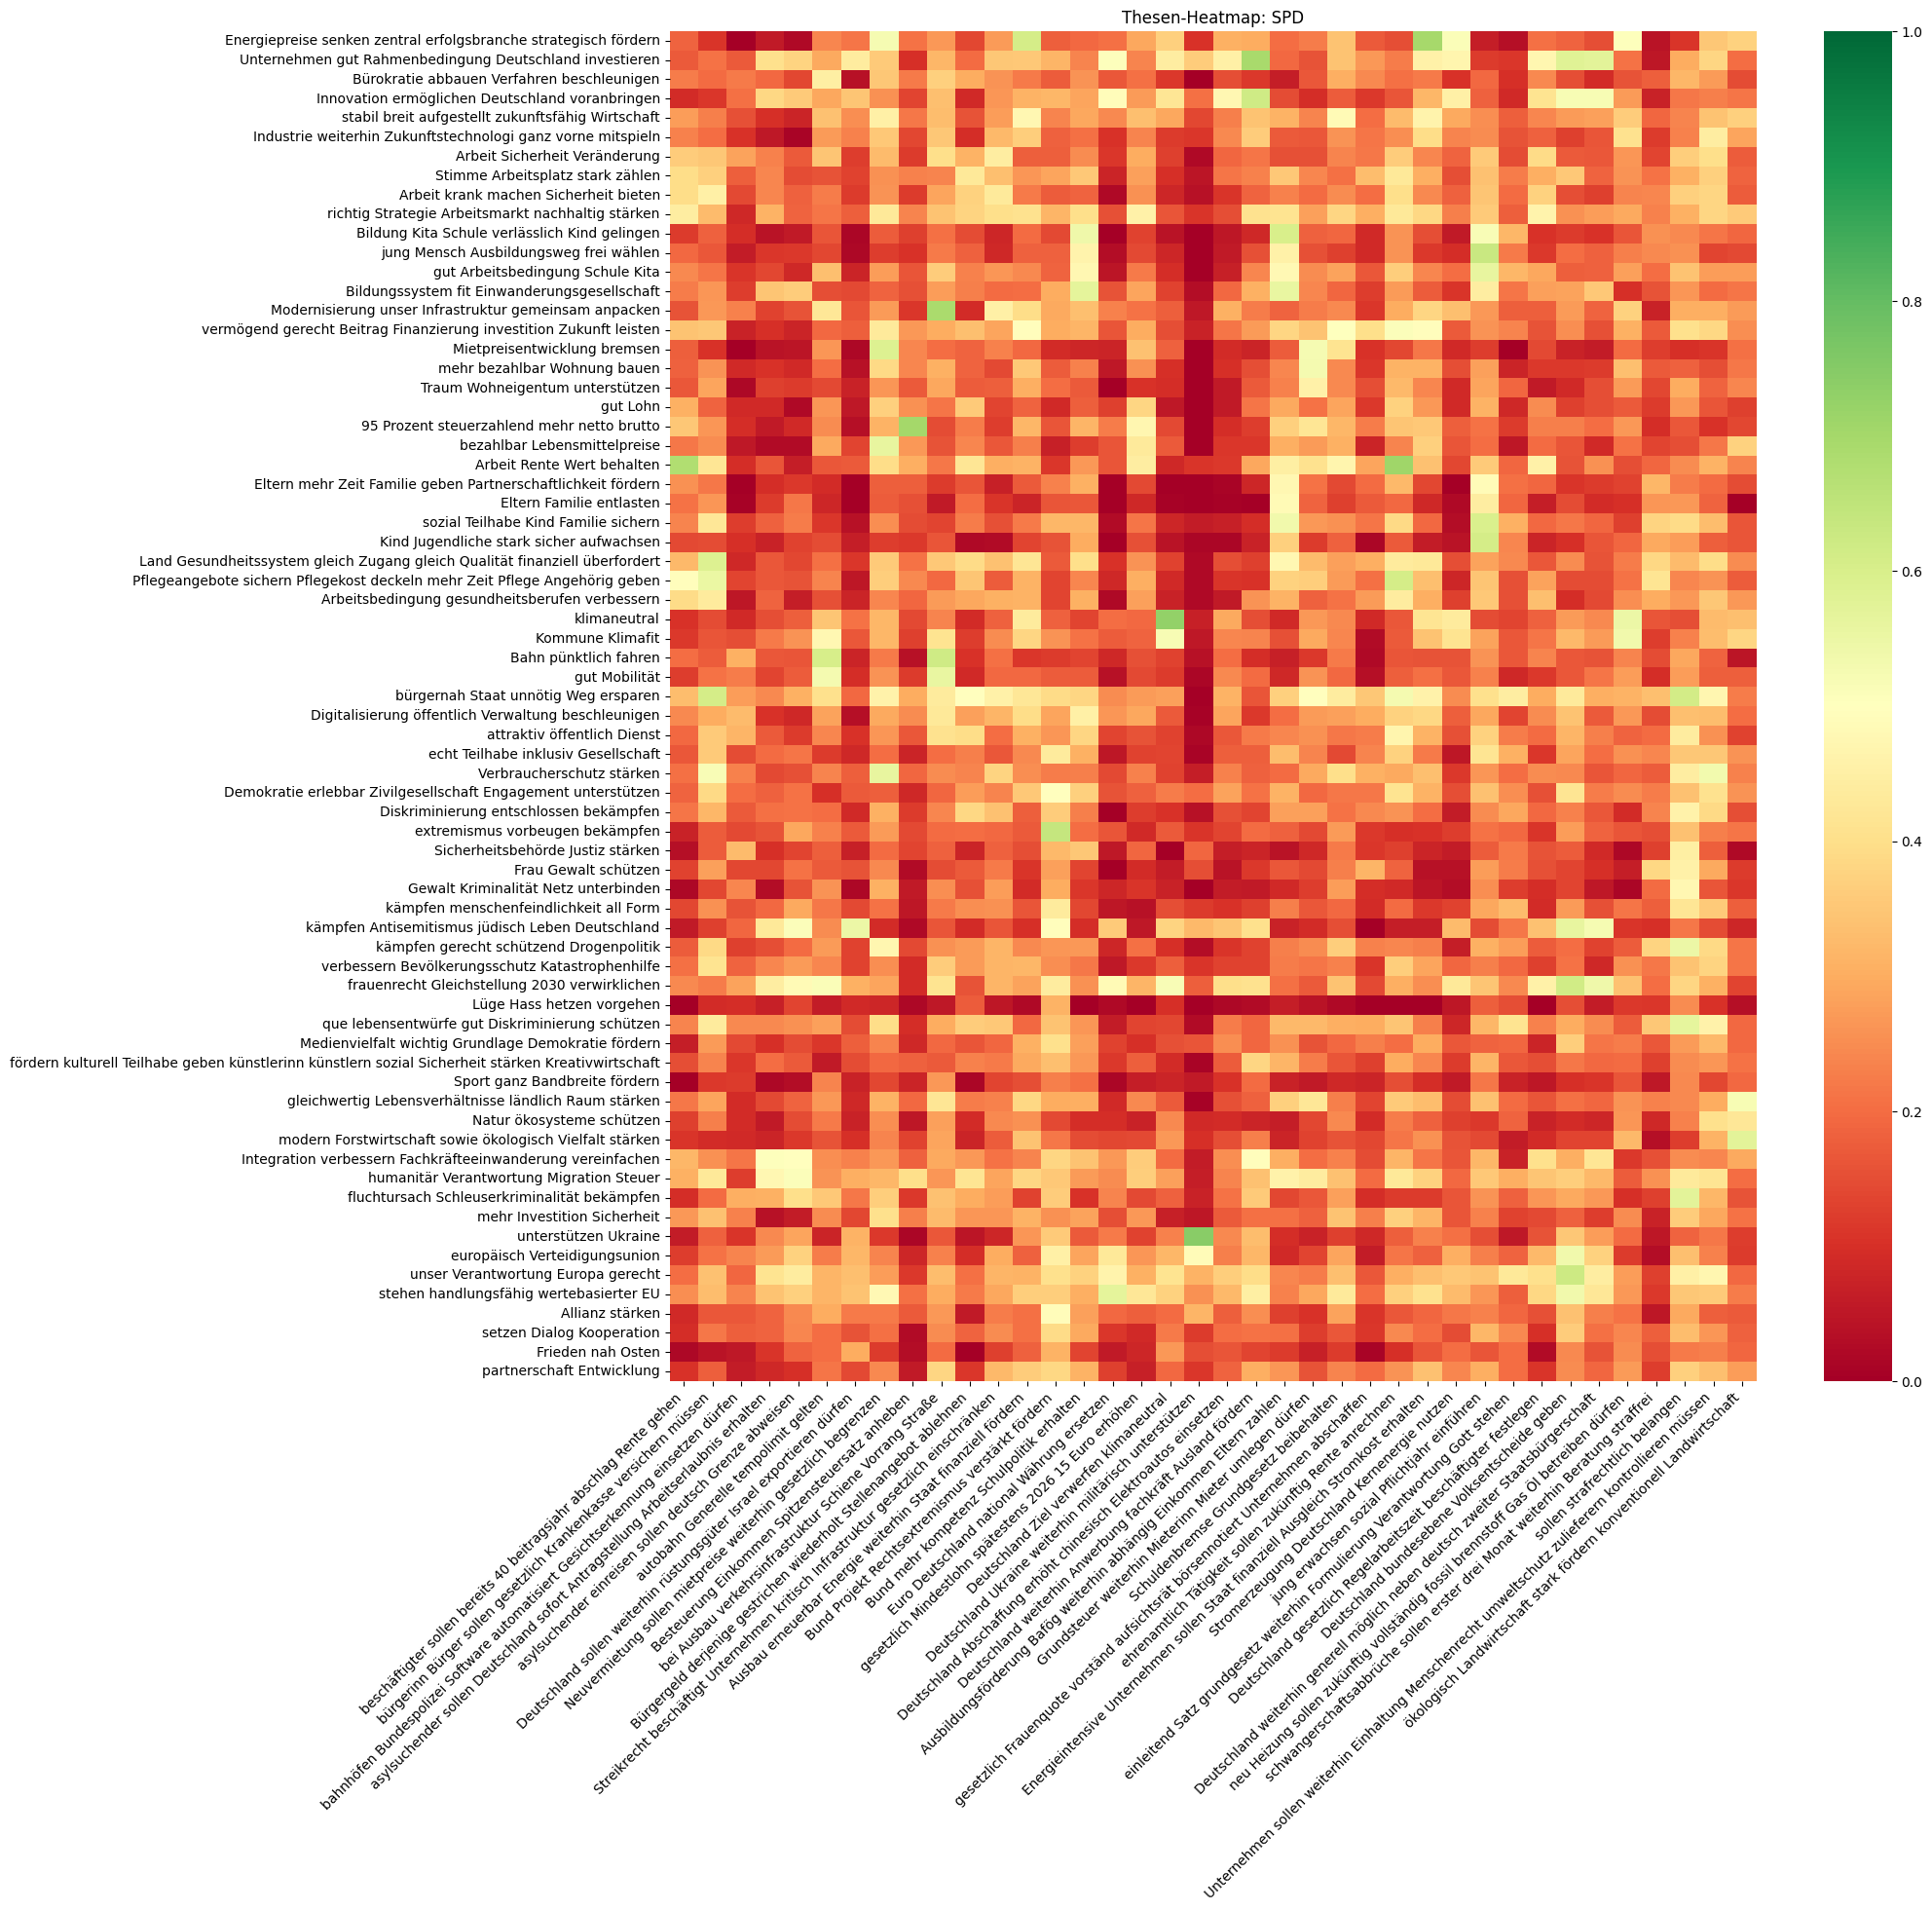

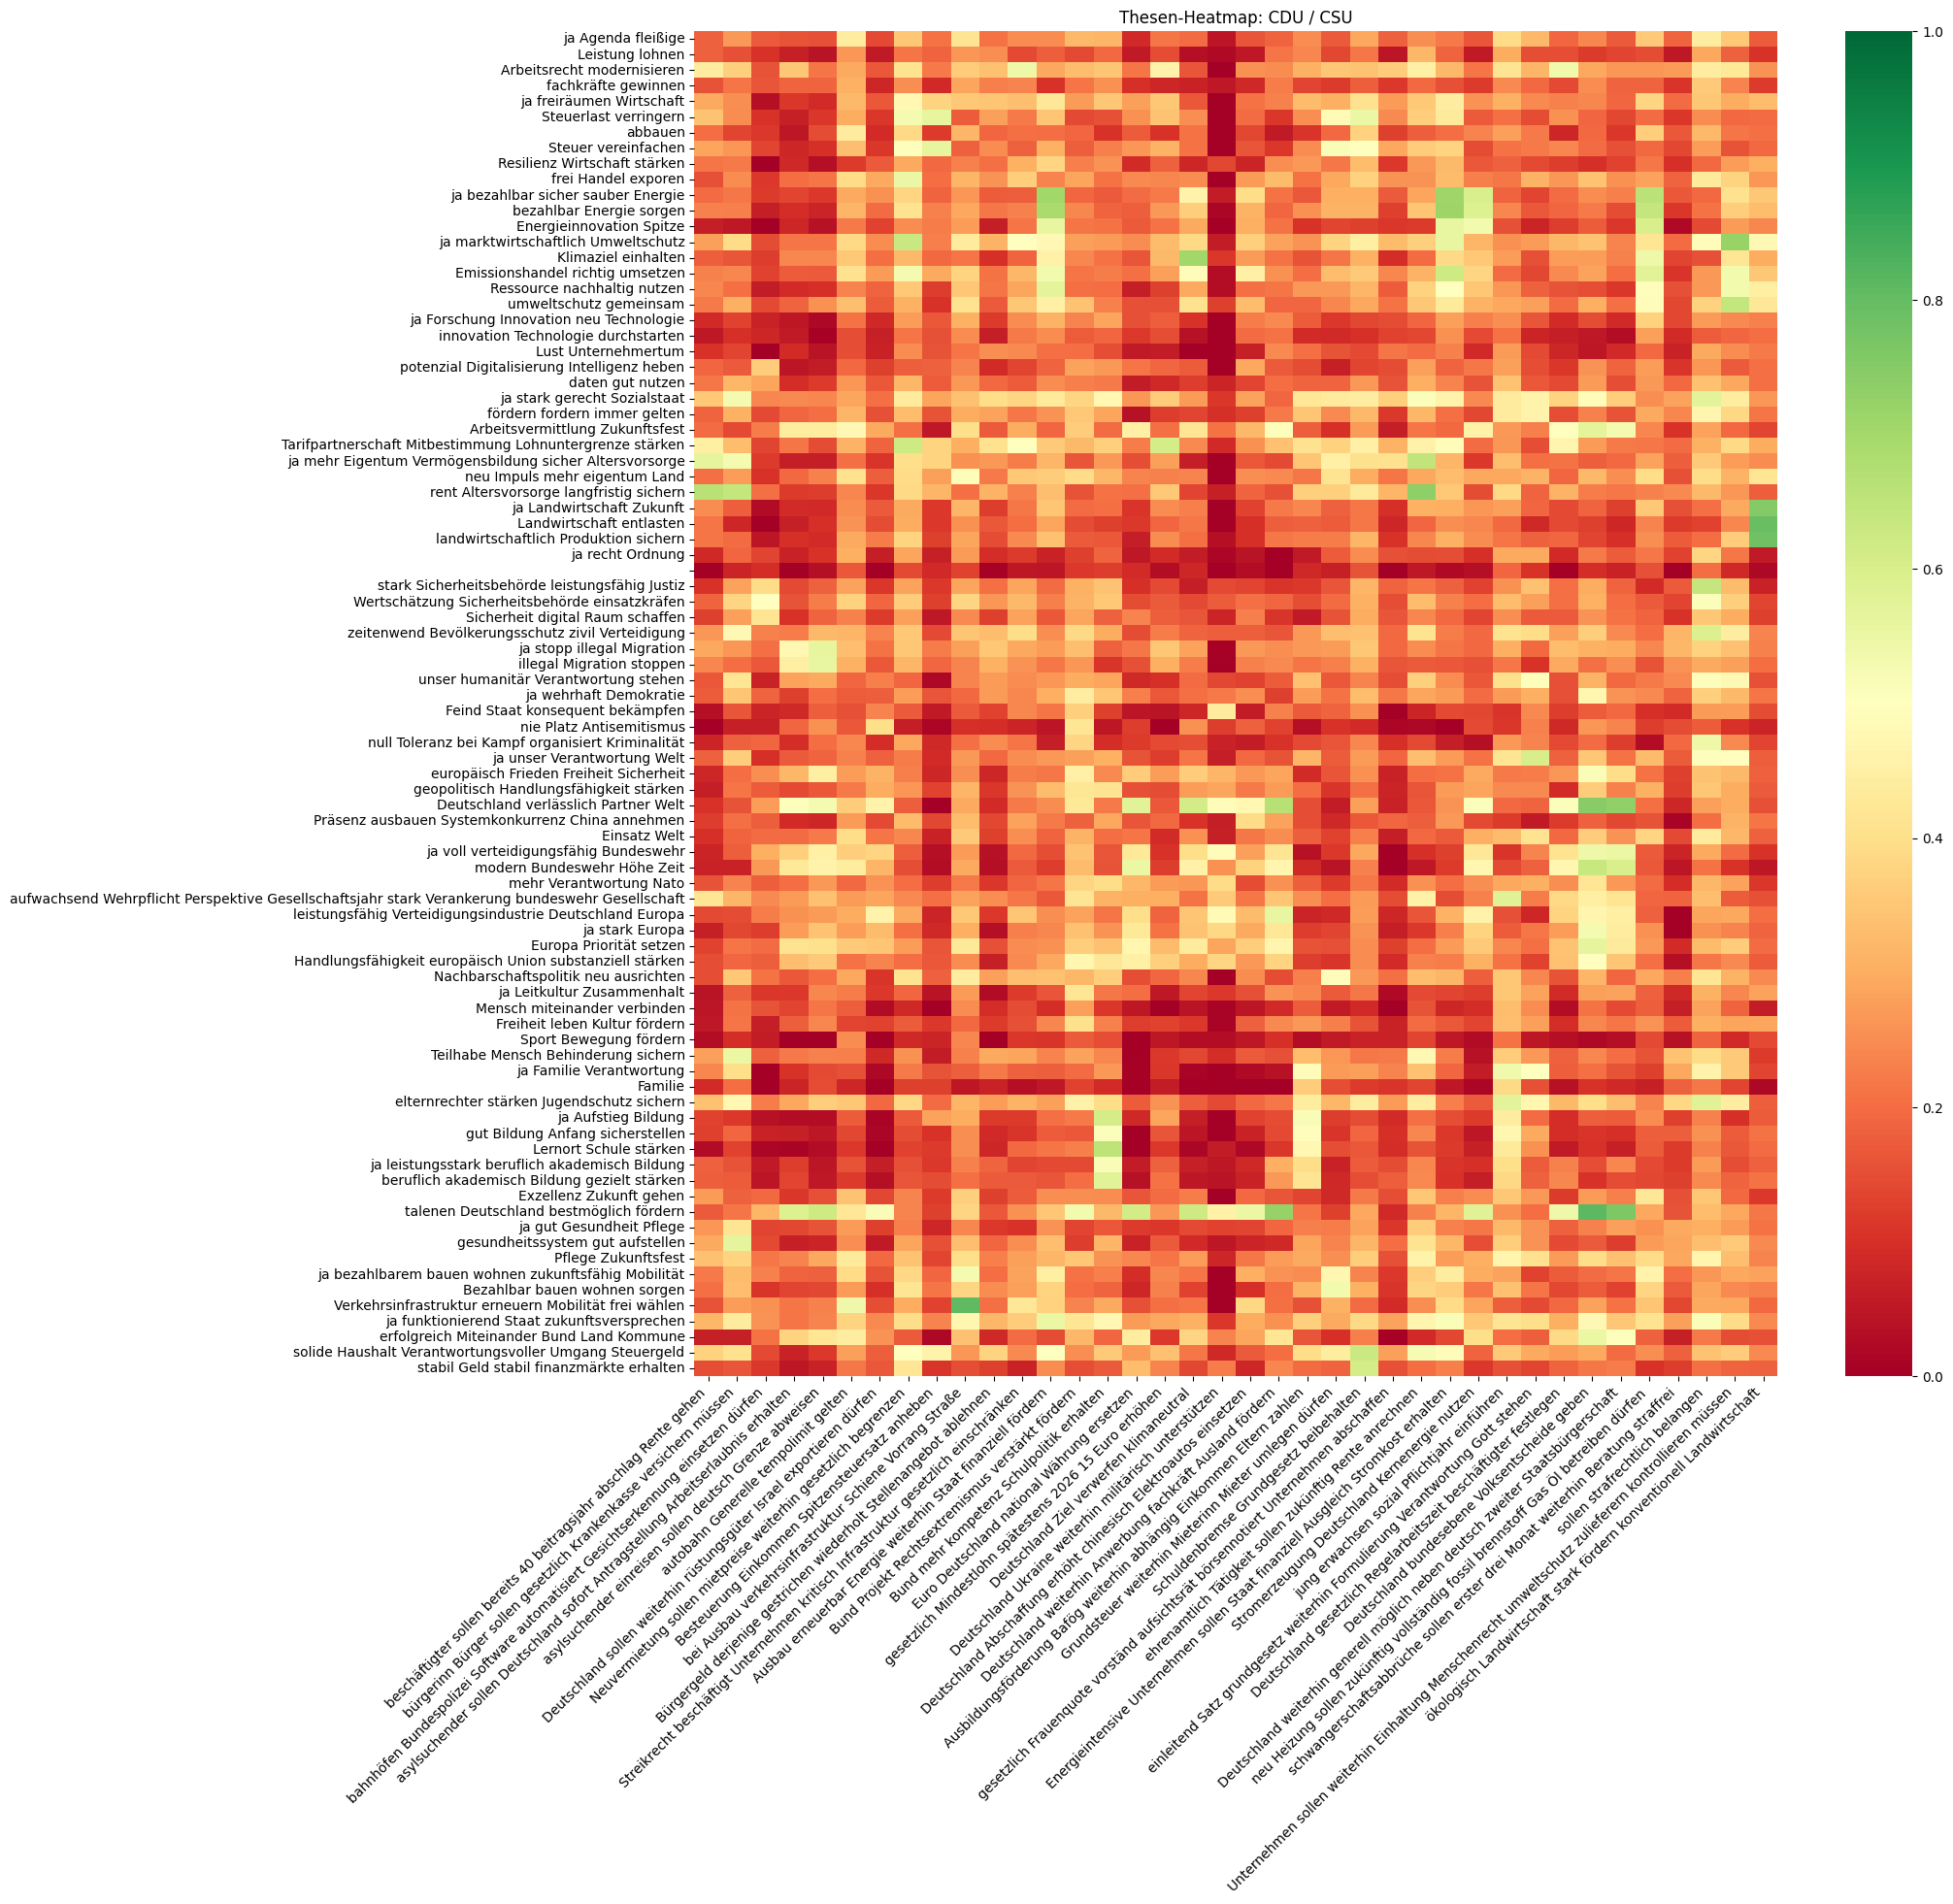

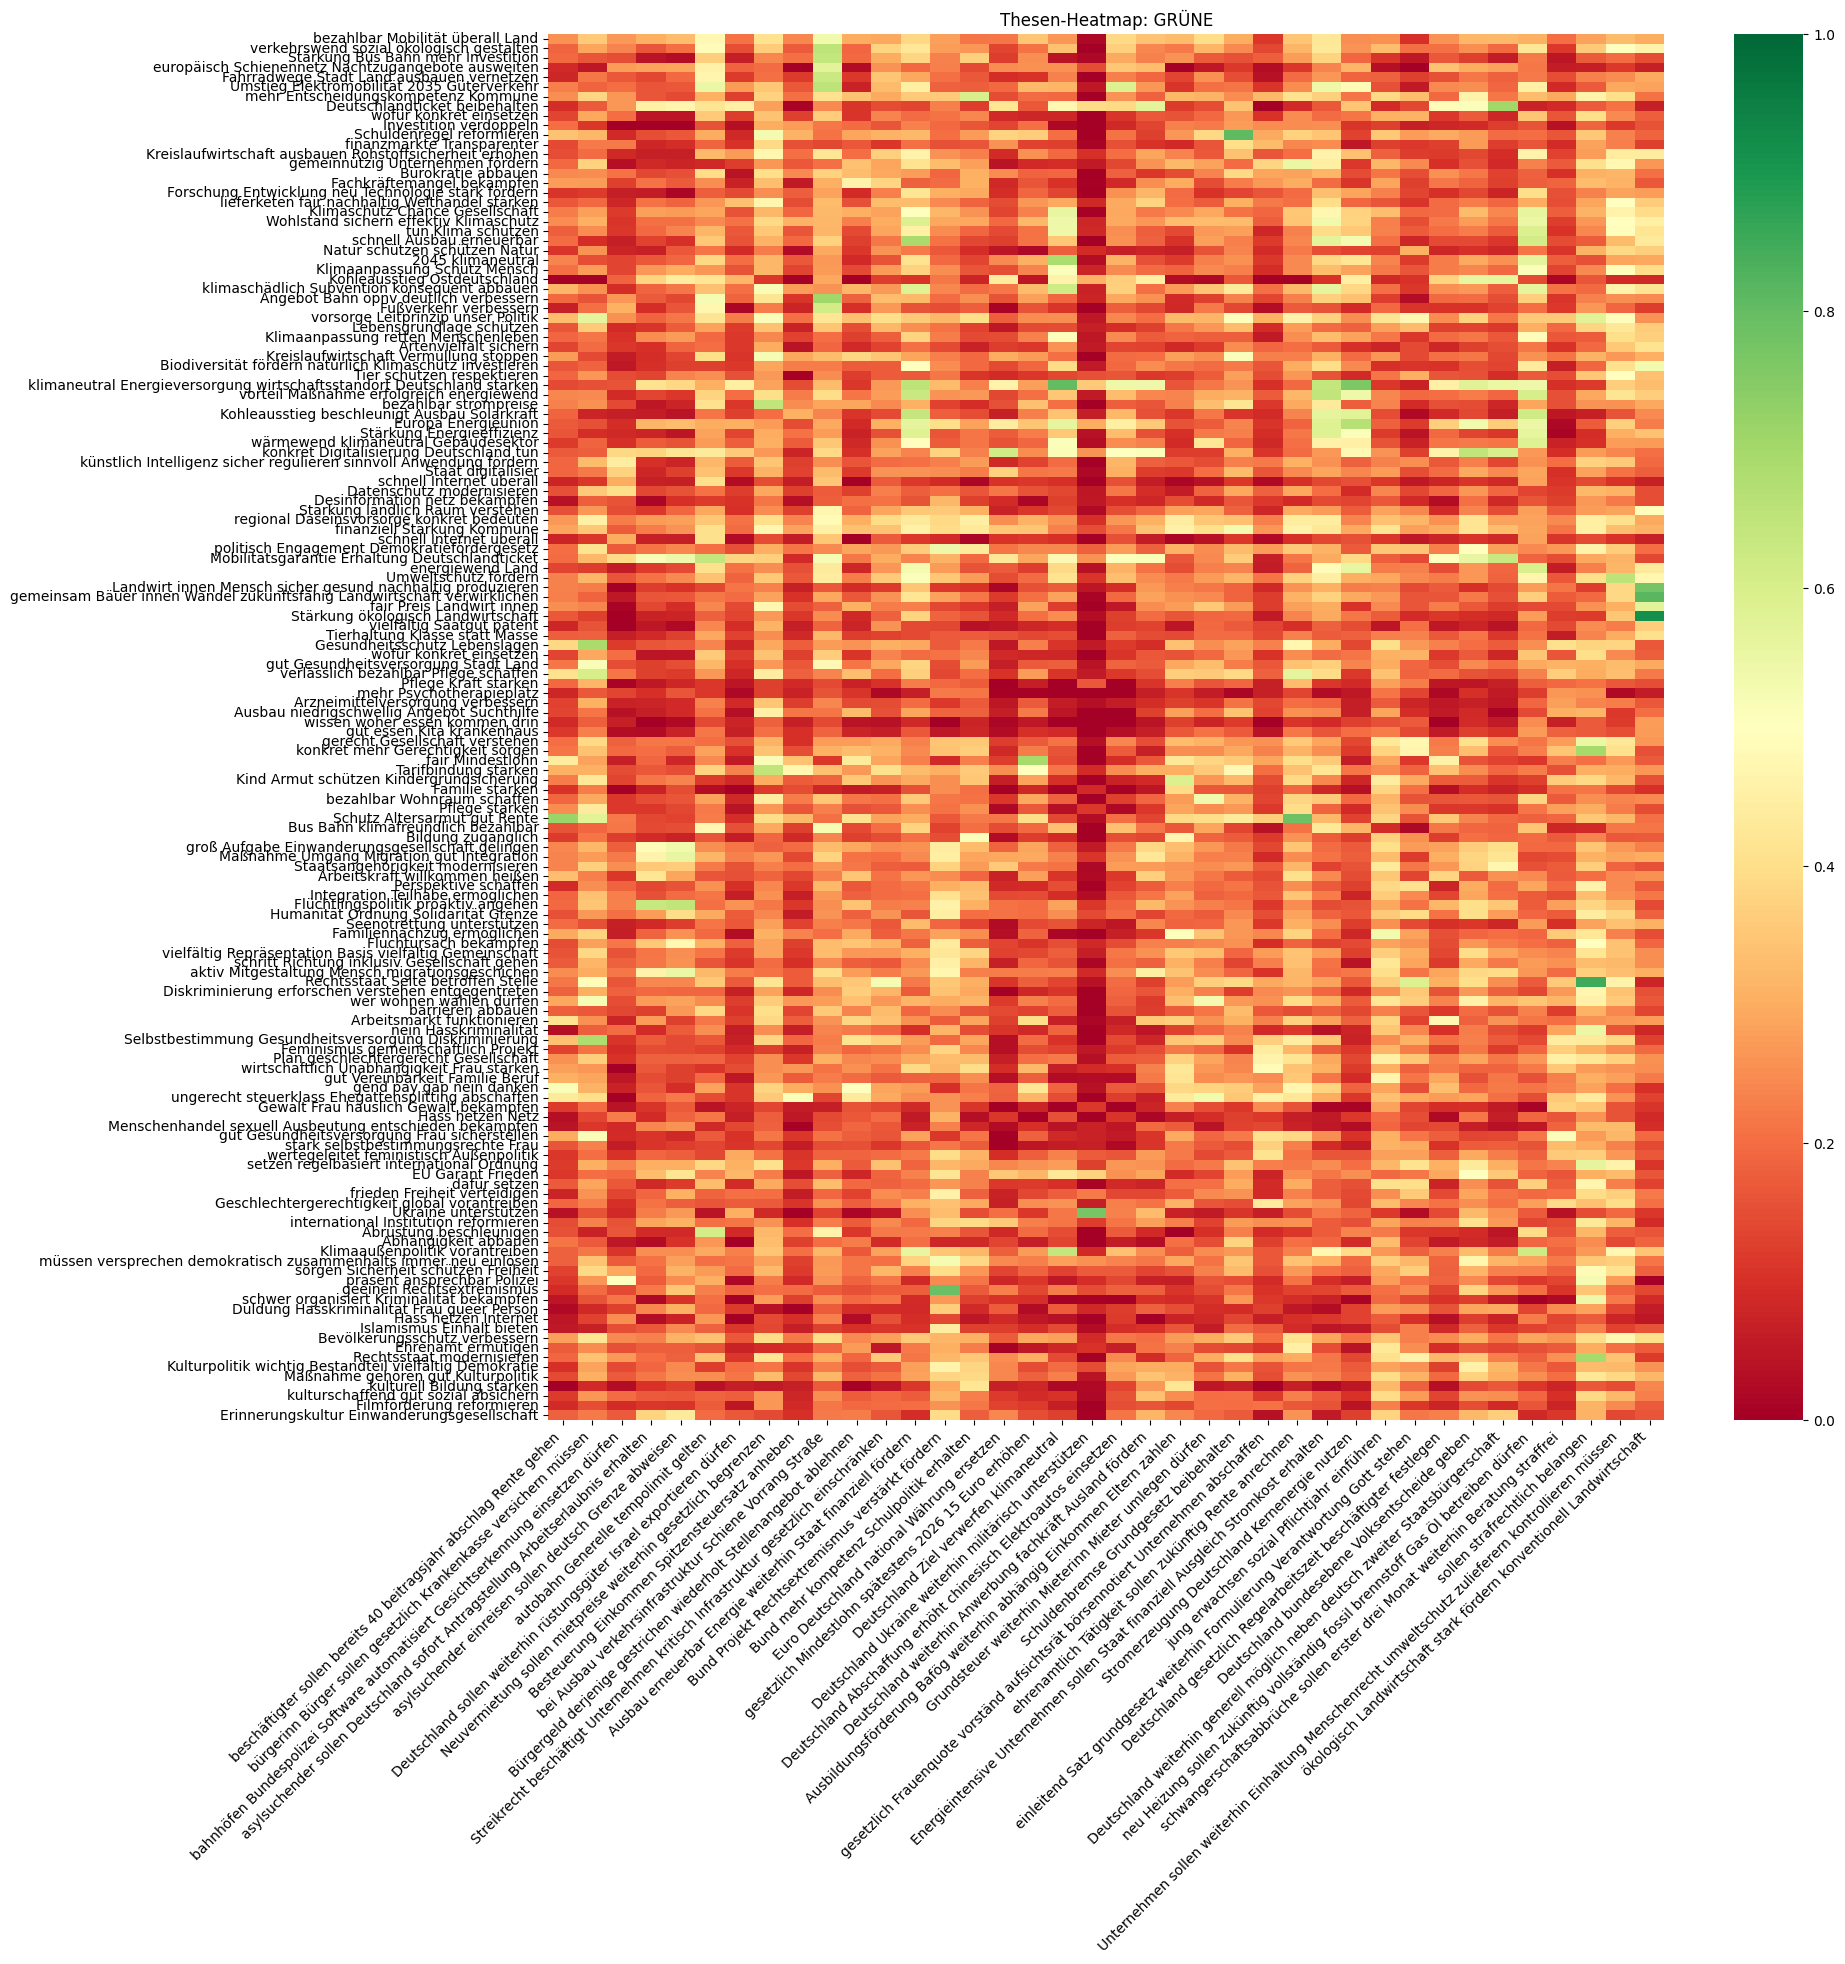

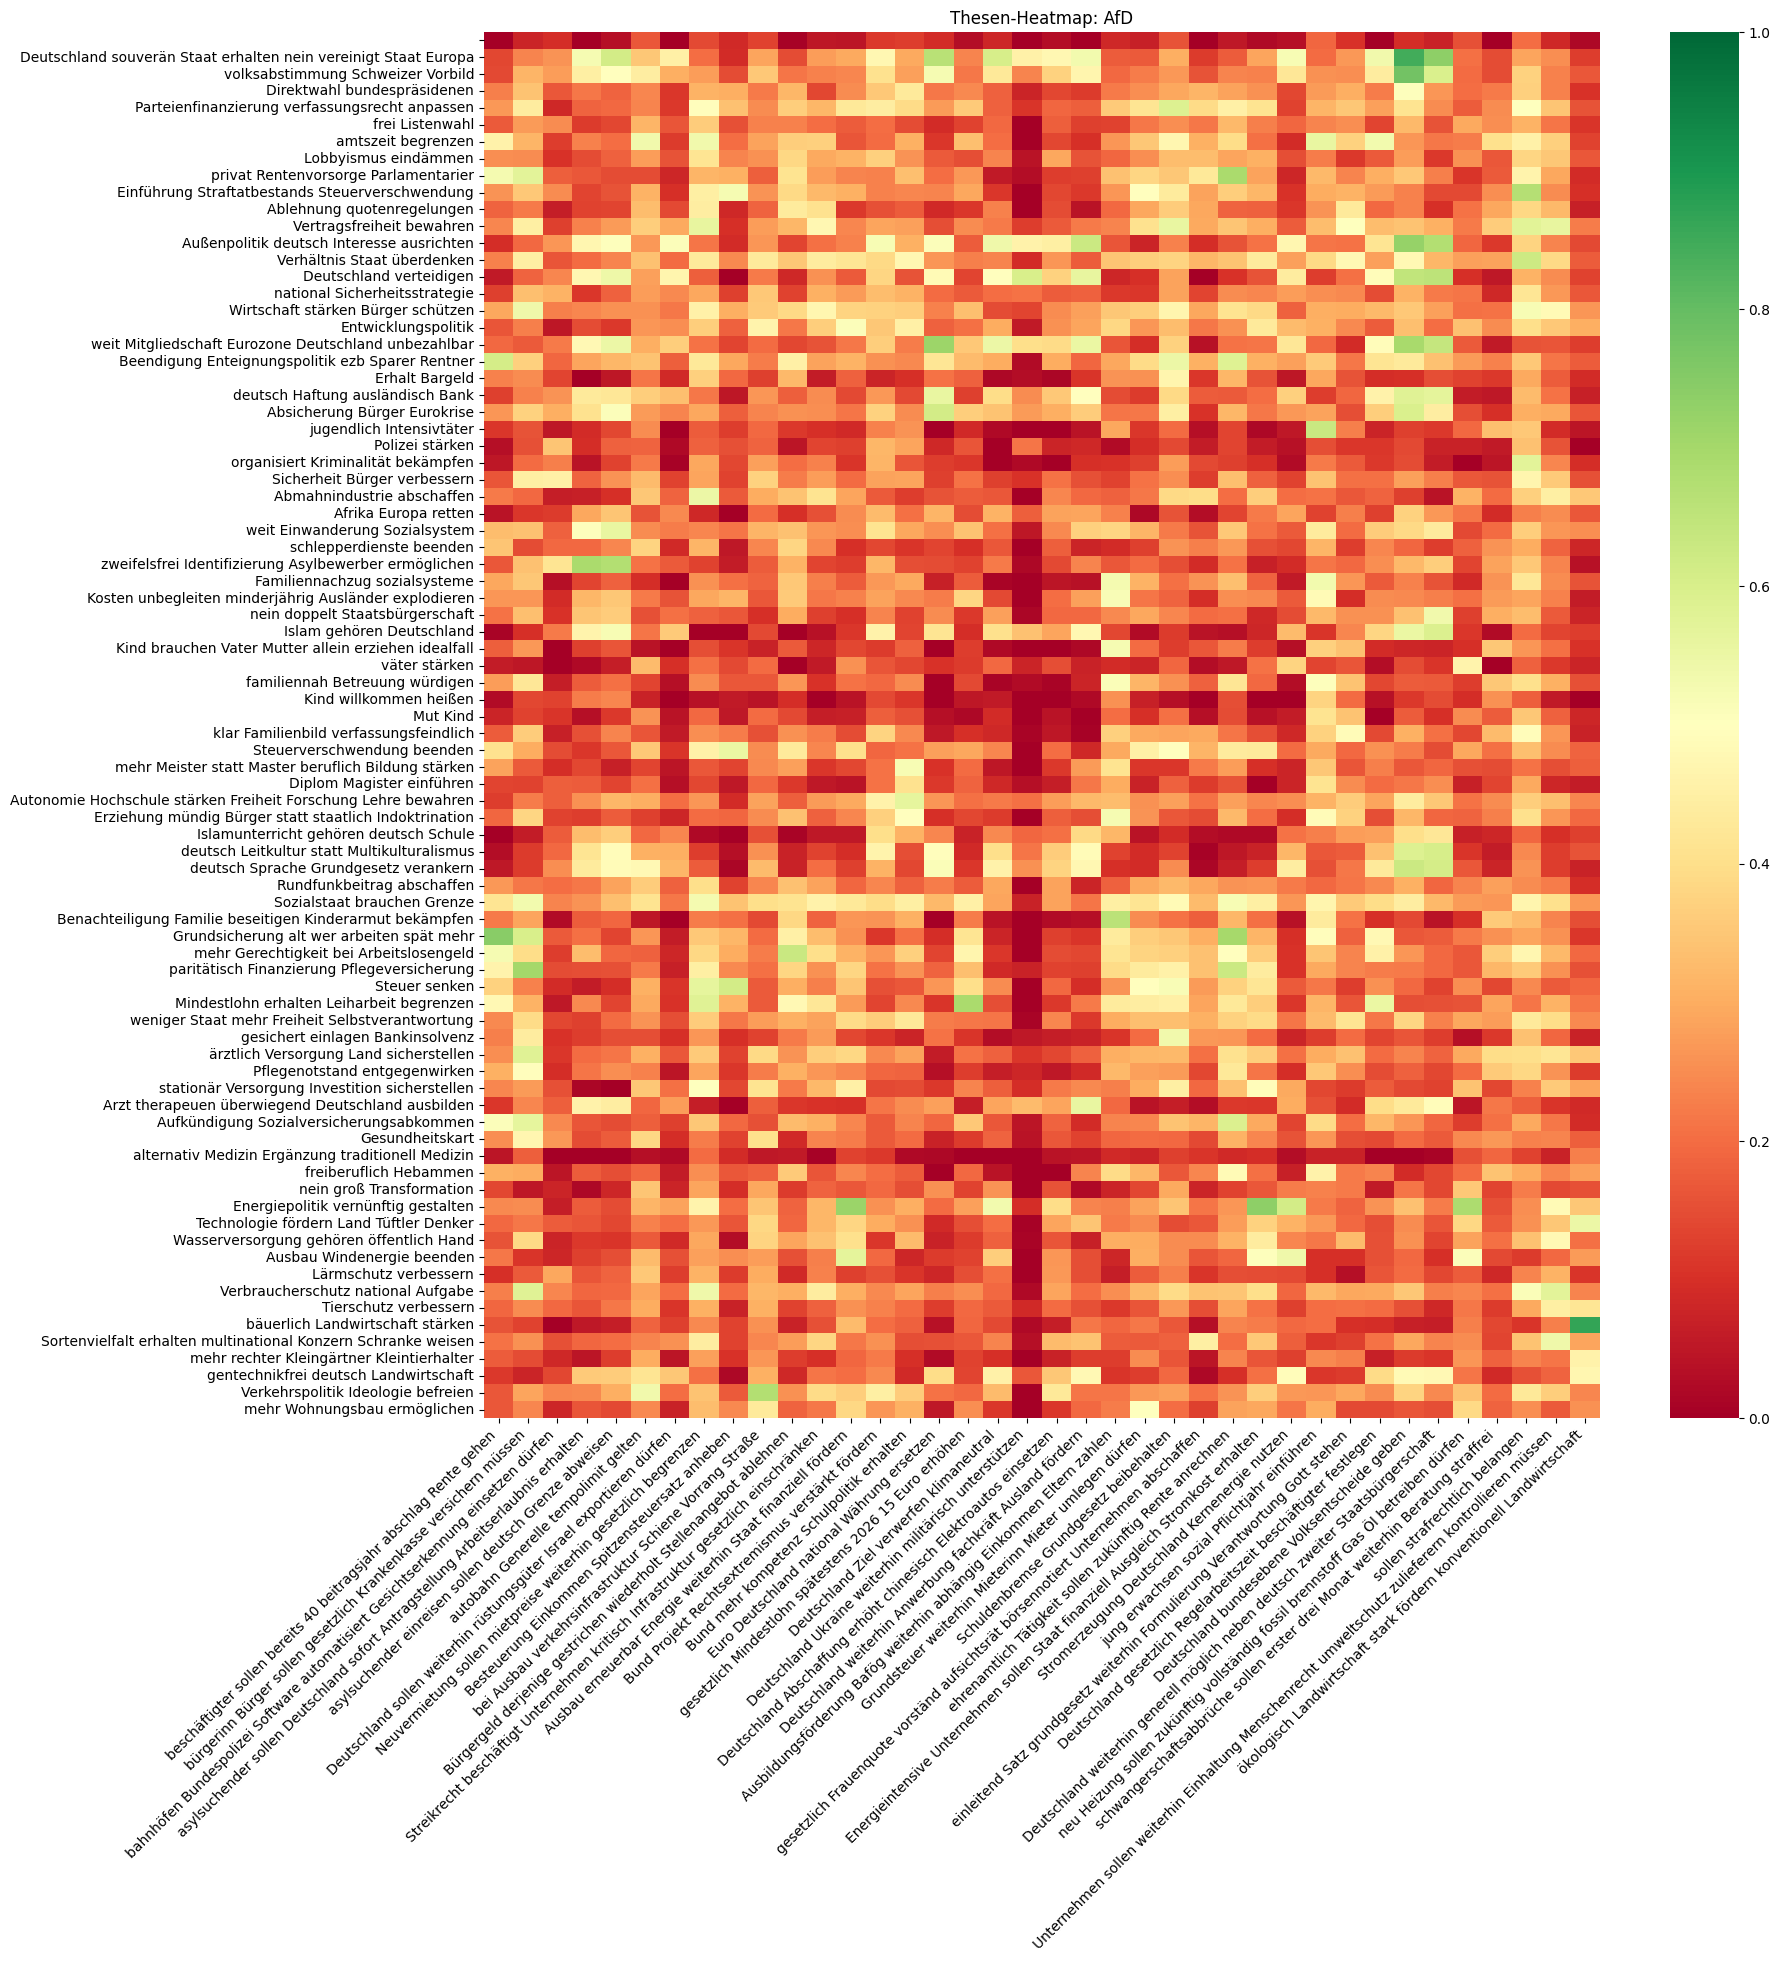

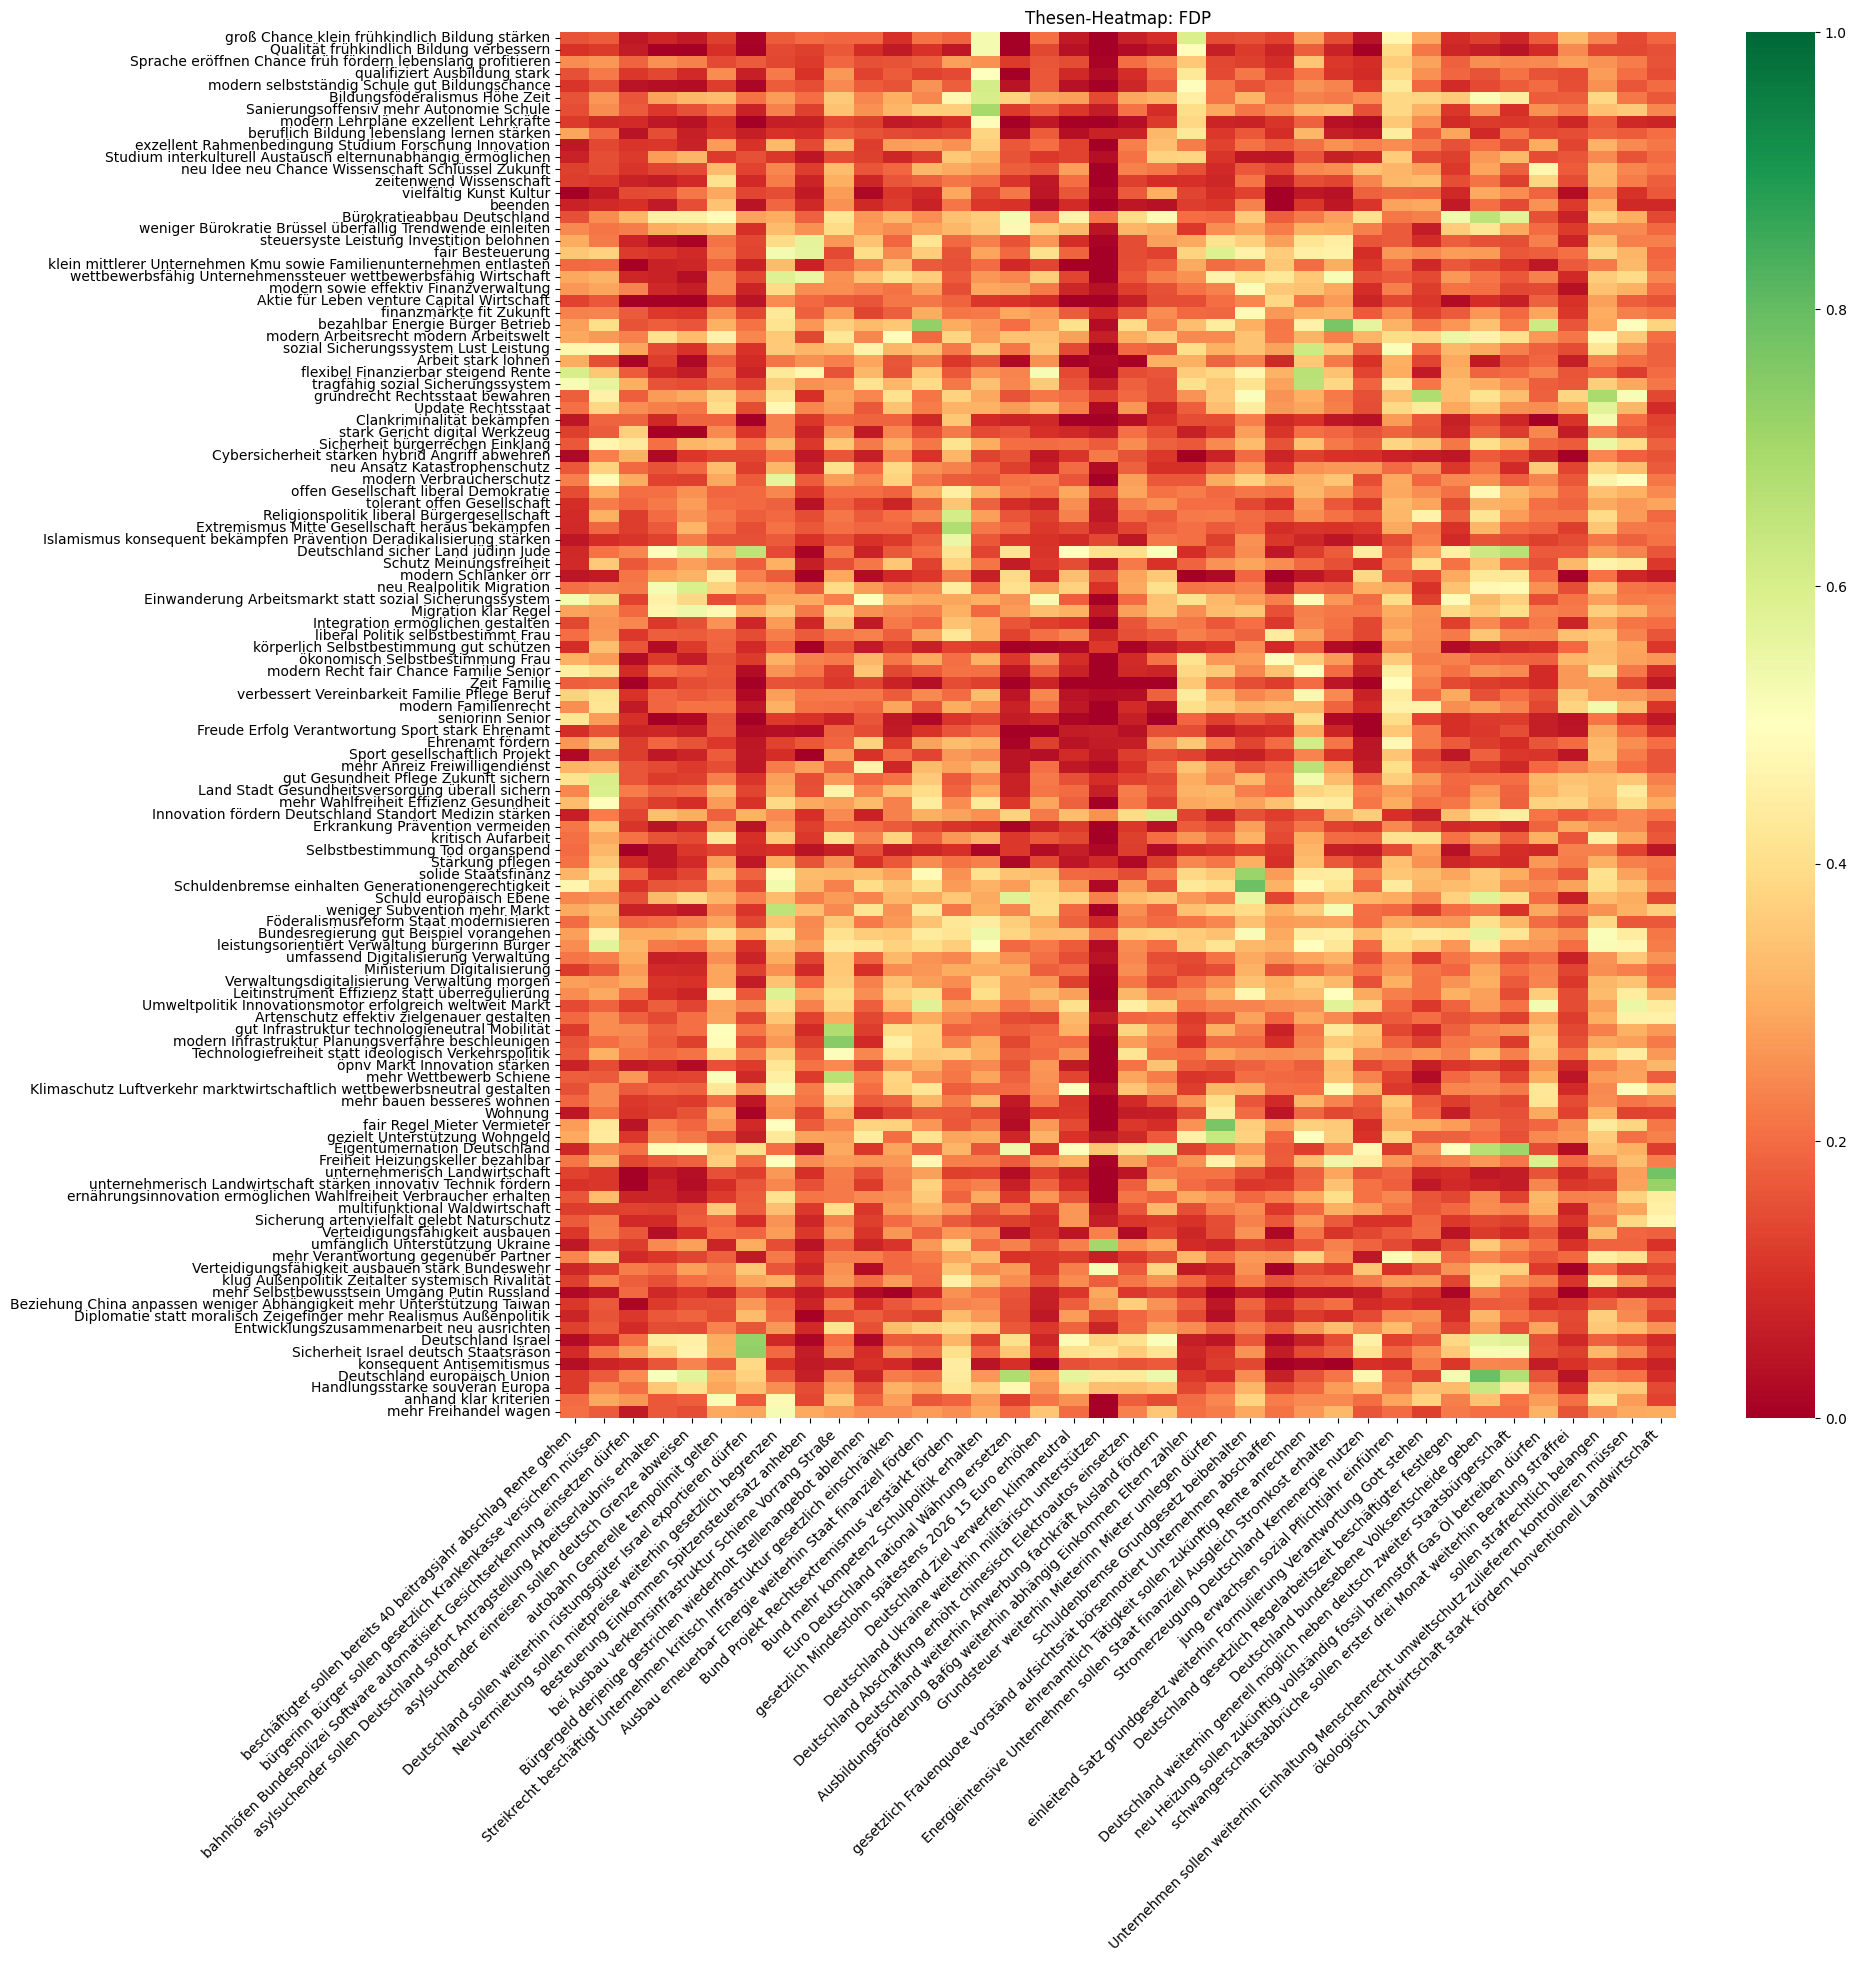

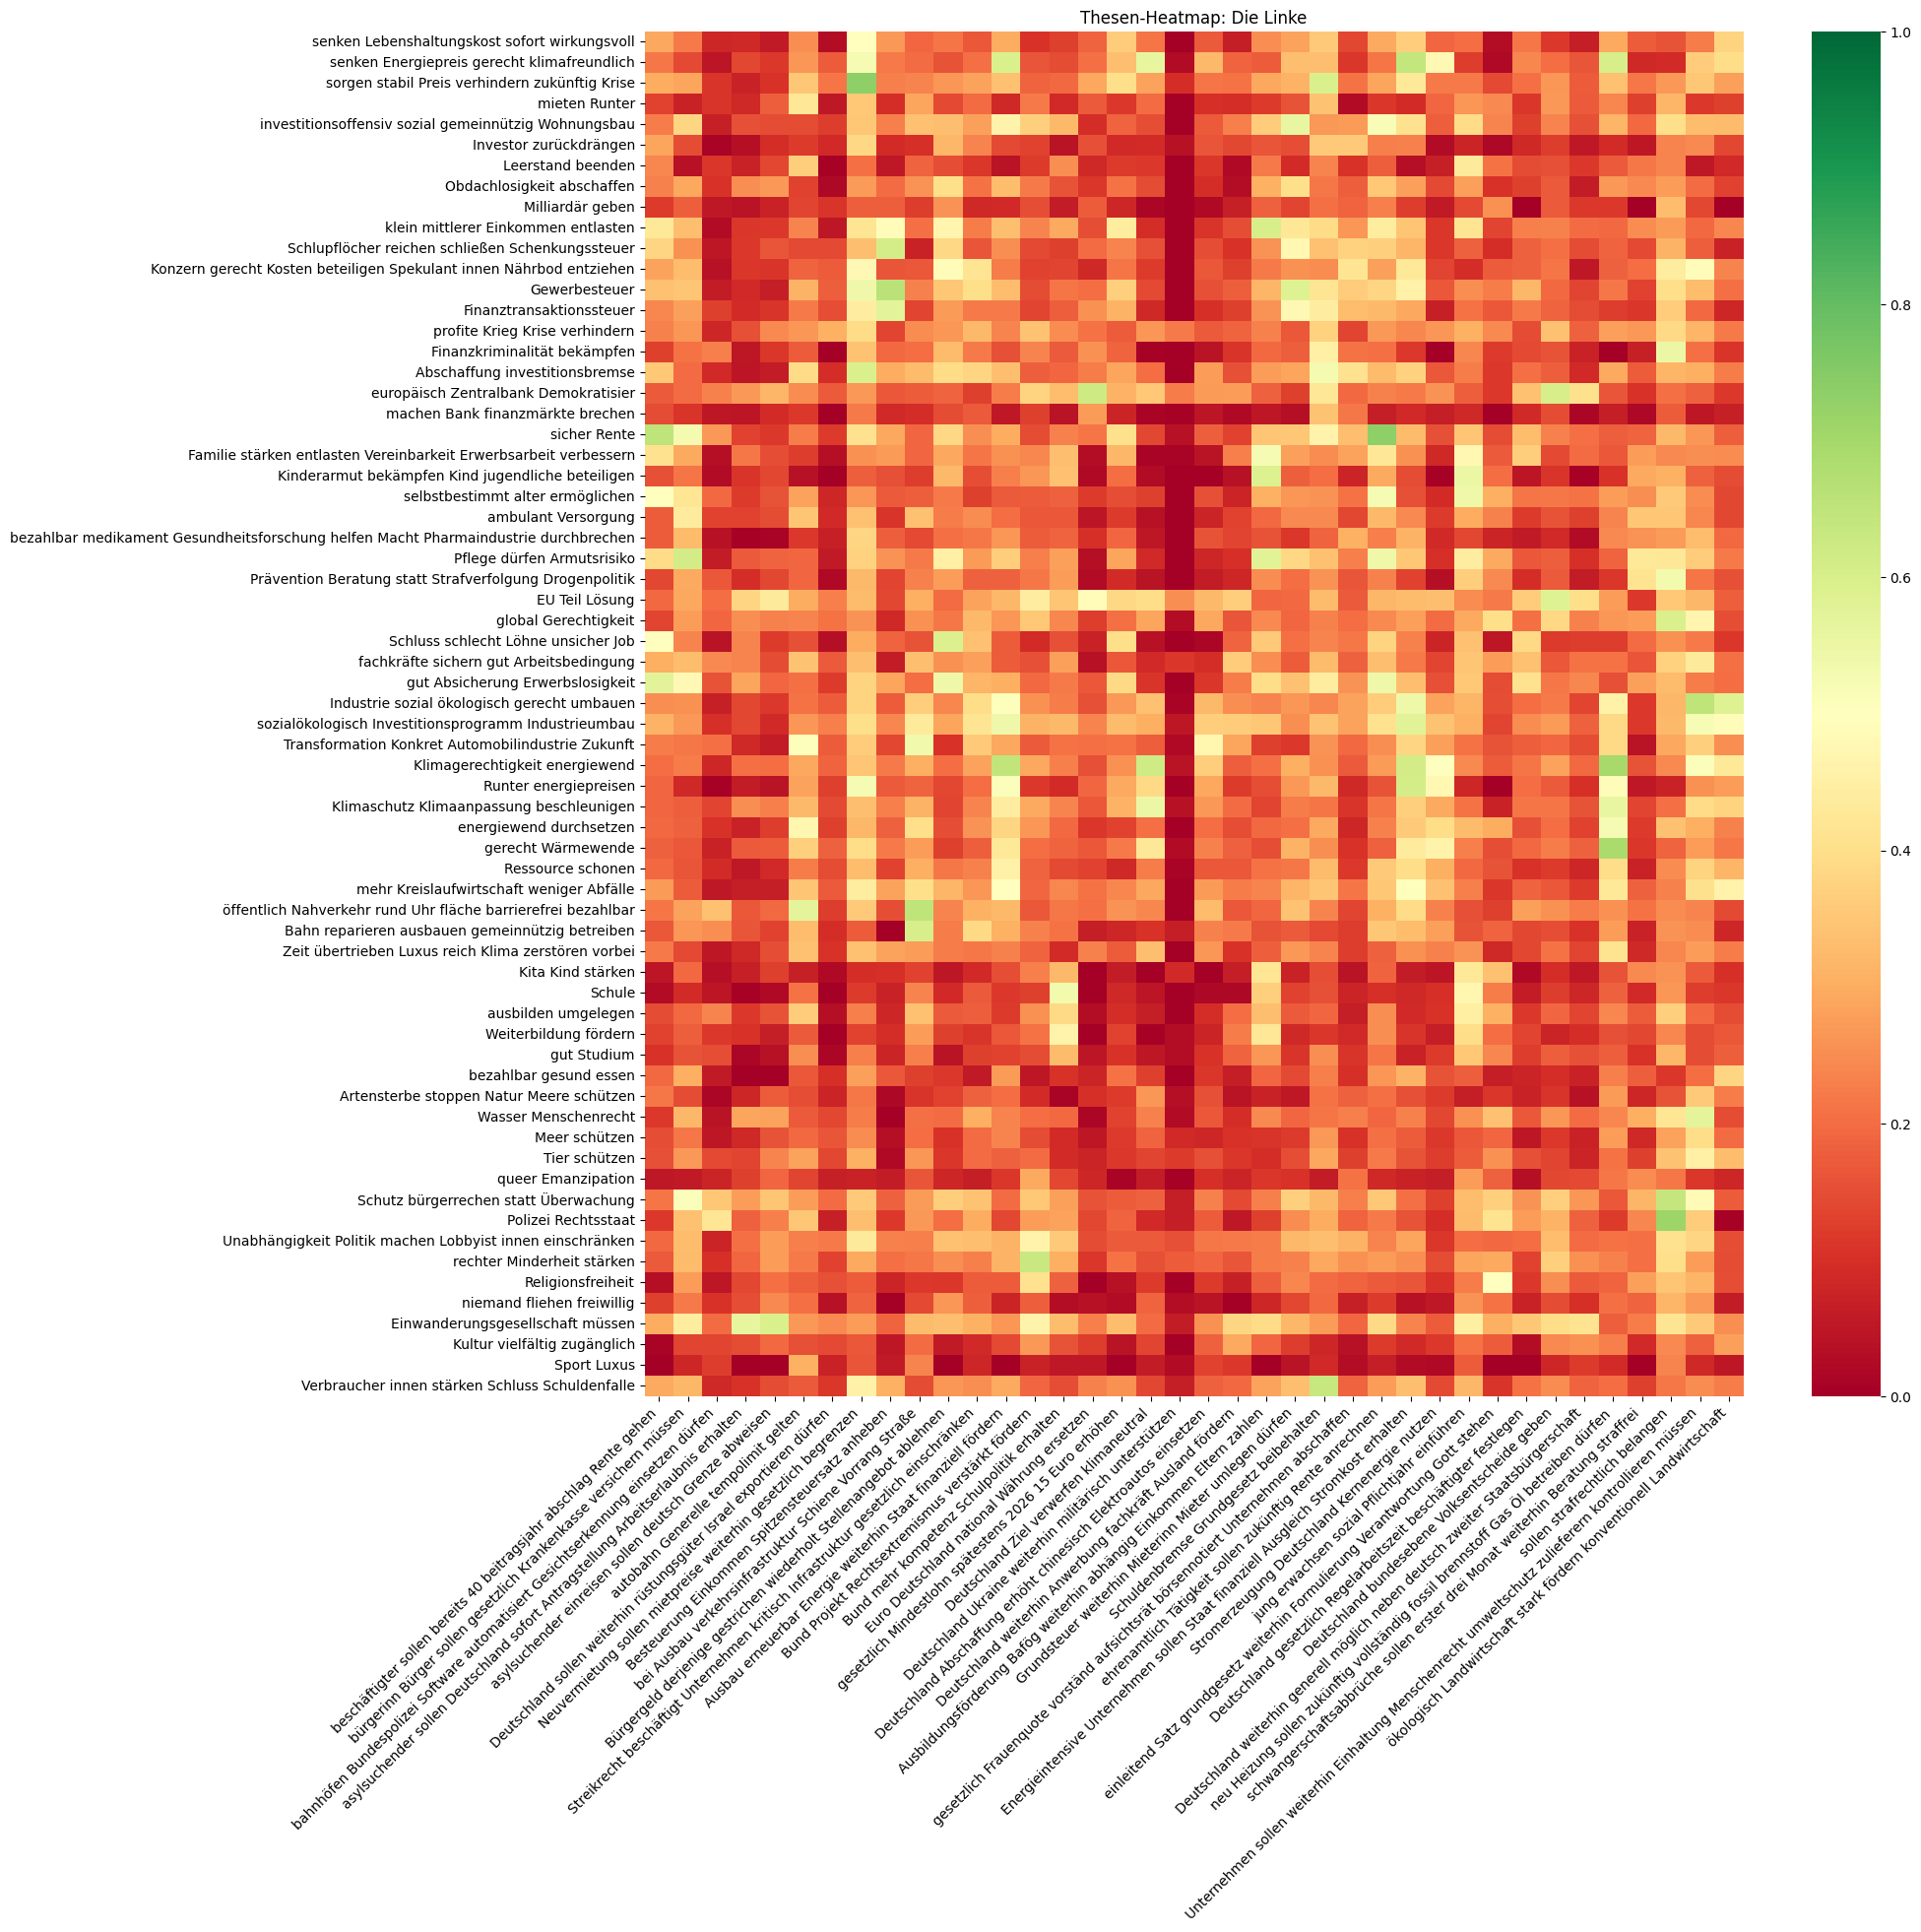

                                               These  \
0  Alle Beschäftigten sollen bereits nach 40 Beit...   
1  Alle Bürgerinnen und Bürger sollen in gesetzli...   
2  An Bahnhöfen soll die Bundespolizei Software z...   
3  Asylsuchende sollen in Deutschland sofort nach...   
4  Asylsuchende, die über einen anderen EU-Staat ...   

                                  These_no_stopwords  \
0  beschäftigten sollen bereits 40 beitragsjahren...   
1  bürgerinnen bürger sollen gesetzlichen kranken...   
2  bahnhöfen bundespolizei software automatisiert...   
3  asylsuchende sollen deutschland sofort antrags...   
4  asylsuchende eingereist sollen deutschen grenz...   

                                    These_lemmatized  \
0  beschäftigter sollen bereits 40 beitragsjahr a...   
1  bürgerinn Bürger sollen gesetzlich Krankenkass...   
2  bahnhöfen Bundespolizei Software automatisiert...   
3  asylsuchender sollen Deutschland sofort Antrag...   
4  asylsuchender einreisen sollen deutsch Gren

In [72]:


# Liste der Parteien und Thesen
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These_lemmatized'].tolist()
predicted_theses_dfs_dict = {}

# Schleife über die Parteien
for party_str in parties_list:
    # Filtern der Daten für die aktuelle Partei
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    
    # Entfernen von Zeilen mit NaN-Werten
    party_df = party_df.dropna()
    
    # Extrahieren der Thesen für die aktuelle Partei
    party_text_list = party_df['These_lemmatized'].to_list()

    # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
    similarity_df = pd.DataFrame(columns=['party_these'] + Labled_theses_list)

    # Berechnung der Ähnlichkeit für jede Partei-These
    for party_text in party_text_list:
        party_these_embedding = model.encode(party_text)
        row = [party_text]

        # Berechnung der Kosinusähnlichkeit für jede labelte These
        for label_these in Labled_theses_list:
            label_these_embedding = model.encode(label_these)
            similarity_score = (cosine_similarity(party_these_embedding.reshape(1, -1), label_these_embedding.reshape(1, -1))[0][0])
            row.append(similarity_score)

        similarity_df.loc[len(similarity_df)] = row

    # Visualisierung der Ähnlichkeiten als Heatmap
    plt.figure(figsize=(18, 18))
    sns.heatmap(similarity_df[Labled_theses_list],
                cmap='RdYlGn',
                annot=False,
                vmax=1,
                vmin=0,
                yticklabels=similarity_df["party_these"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    # Maximale Ähnlichkeit für jede Partei
    predicted_theses_dfs_dict[party_str] = similarity_df
    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].max().tolist()
    
# Ausgabe der ersten Zeilen des DataFrames mit den Vorhersagen
print(predicted_theses_df.head())


In [73]:
display(predicted_theses_df)

,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,0.662384,0.716219,0.677031,0.743315,0.651245,0.603904
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,0.642848,0.688126,0.607927,0.702415,0.611292,0.601625
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,0.497476,0.503671,0.327842,0.452874,0.418622,0.436712
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,0.589178,0.636255,0.505712,0.690684,0.560742,0.524817
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,0.622486,0.645327,0.510625,0.673277,0.597496,0.596684
5,Auf allen Autobahnen soll ein generelles Tempo...,autobahnen generelles tempolimit gelten,autobahn Generelle tempolimit gelten,autobahn Generelle tempolimit gelten,0.540376,0.638696,0.601947,0.537741,0.566521,0.515924
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,deutschland sollen weiterhin rüstungsgüter isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,0.516052,0.450743,0.549258,0.509481,0.307268,0.727774
7,Bei Neuvermietungen sollen die Mietpreise weit...,neuvermietungen sollen mietpreise weiterhin ge...,Neuvermietung sollen mietpreise weiterhin gese...,Neuvermietung sollen mietpreise weiterhin gese...,0.632750,0.647889,0.588763,0.580208,0.734411,0.654769
8,Bei der Besteuerung von Einkommen soll der Spi...,besteuerung einkommen spitzensteuersatz angehoben,Besteuerung Einkommen Spitzensteuersatz anheben,Besteuerung Einkommen Spitzensteuersatz anheben,0.562240,0.515148,0.700086,0.613164,0.658698,0.567913
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,beim ausbau verkehrsinfrastruktur schiene vorr...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,0.805202,0.704441,0.690937,0.673680,0.649857,0.743798


In [83]:
lable_mapping_dict = {
    1/6 : "stimme nicht zu", # 0,00 - 0,33 
    3/6 : "neutral",         # 0,33 - 0,66 
    5/6 : "stimme zu"        # 0,66 - 1,00
}

# Mapping-Dictionary definieren
label_mapping_dict = {
    1/6: "stimme nicht zu",  # 0,00 - 0,33
    3/6: "neutral",          # 0,33 - 0,66
    5/6: "stimme zu"         # 0,66 - 1,00
}

# Funktion zum Anwenden des Mappings basierend auf den Werten
def map_values_with_dict(val):
    if val <= 1/6:
        return label_mapping_dict[1/6]
    elif val <= 3/6:
        return label_mapping_dict[3/6]
    else:
        return label_mapping_dict[5/6]

# Kopieren des DataFrames und Anwenden des Mappings
predicted_theses_df_mapped = predicted_theses_df.copy()

# Anwenden der Mapping-Funktion auf alle Spalten außer der ersten
for col in predicted_theses_df.columns[4:]:
    predicted_theses_df_mapped[col] = predicted_theses_df[col].apply(map_values_with_dict)

# Anzeigen des gemappten DataFrames
display(predicted_theses_df_mapped)


,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,neutral,stimme zu,neutral,neutral,neutral,neutral
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,autobahnen generelles tempolimit gelten,autobahn Generelle tempolimit gelten,autobahn Generelle tempolimit gelten,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,deutschland sollen weiterhin rüstungsgüter isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,stimme zu,neutral,stimme zu,stimme zu,neutral,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,neuvermietungen sollen mietpreise weiterhin ge...,Neuvermietung sollen mietpreise weiterhin gese...,Neuvermietung sollen mietpreise weiterhin gese...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
8,Bei der Besteuerung von Einkommen soll der Spi...,besteuerung einkommen spitzensteuersatz angehoben,Besteuerung Einkommen Spitzensteuersatz anheben,Besteuerung Einkommen Spitzensteuersatz anheben,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,beim ausbau verkehrsinfrastruktur schiene vorr...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu


In [74]:
import os
import pickle


file_name_all_similaritys = f'paraphrase-multilingual-mpnet-base-v2.pkl' 
file_name_max_similaritys = f'paraphrase-multilingual-mpnet-base-v2.parquet' 


with open(file_name_all_similaritys, 'wb') as f:
    pickle.dump(predicted_theses_dfs_dict, f)

predicted_theses_df.to_parquet(file_name_max_similaritys, index=False)



In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calc_prediction_scores_func(predicted_theses_df:pd.DataFrame, label_these_num_df:pd.DataFrame)->pd.DataFrame:
    scores_df = pd.DataFrame(columns= ['score'])
    scores_df['score'] = ['RMSE', 'MAE', 'R²']
    for col in predicted_theses_df.columns[4:]: 
        predicted_values = predicted_theses_df[col]
        true_values = label_these_num_df[col]

        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        r2 = r2_score(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        scores_df[col] = [rmse, mae, r2]


    return scores_df



In [77]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = Labled_theses_df.copy()
for col in Labled_theses_df.columns[4:]:
    label_these_num_df[col] = Labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.380287,0.345922,0.307348,0.377163,0.323058,0.368568
1,MAE,0.340255,0.298986,0.278764,0.333011,0.298843,0.323719
2,R²,-0.422755,-0.113193,0.059283,-0.475424,0.008517,-0.405581


In [78]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = Labled_theses_df.copy()
for col in Labled_theses_df.columns[1:]:
    label_these_num_df[col] = Labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.380287,0.345922,0.307348,0.377163,0.323058,0.368568
1,MAE,0.340255,0.298986,0.278764,0.333011,0.298843,0.323719
2,R²,-0.422755,-0.113193,0.059283,-0.475424,0.008517,-0.405581


In [80]:
pd.concat([predicted_theses_df['These'], predicted_theses_df.select_dtypes(include='number')-label_these_num_df.select_dtypes(include='number')], axis=1)

,These,AfD,CDU / CSU,Die Linke,FDP,GRÜNE,SPD,These_lemmatized,These_no_stopwords,These_unique_words
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.576649,0.495717,-0.182088,0.437237,0.549553,0.510364,NaN,NaN,NaN
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.535749,0.476181,-0.222042,0.434958,-0.145207,-0.225406,NaN,NaN,NaN
2,An Bahnhöfen soll die Bundespolizei Software z...,-0.380459,-0.335857,0.251956,0.270045,0.337005,0.161175,NaN,NaN,NaN
3,Asylsuchende sollen in Deutschland sofort nach...,0.524018,0.422511,-0.272591,0.024817,-0.197078,-0.327621,NaN,NaN,NaN
4,"Asylsuchende, die über einen anderen EU-Staat ...",-0.160057,-0.210847,0.430829,-0.236650,0.478660,0.343958,NaN,NaN,NaN
5,Auf allen Autobahnen soll ein generelles Tempo...,0.371074,0.373709,-0.266812,0.349257,-0.194637,-0.231386,NaN,NaN,NaN
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.009481,-0.317282,0.140602,-0.105559,-0.382590,-0.284075,NaN,NaN,NaN
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.413541,-0.200583,-0.098922,0.488103,-0.185445,-0.244570,NaN,NaN,NaN
8,Bei der Besteuerung von Einkommen soll der Spi...,0.446497,0.395574,-0.174635,0.401246,-0.318185,-0.133247,NaN,NaN,NaN
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.507014,0.638535,-0.183476,0.577131,-0.128892,-0.142396,NaN,NaN,NaN


### Überprüfung der Similarity der Wahlomat-These zu den Texten der Parteien


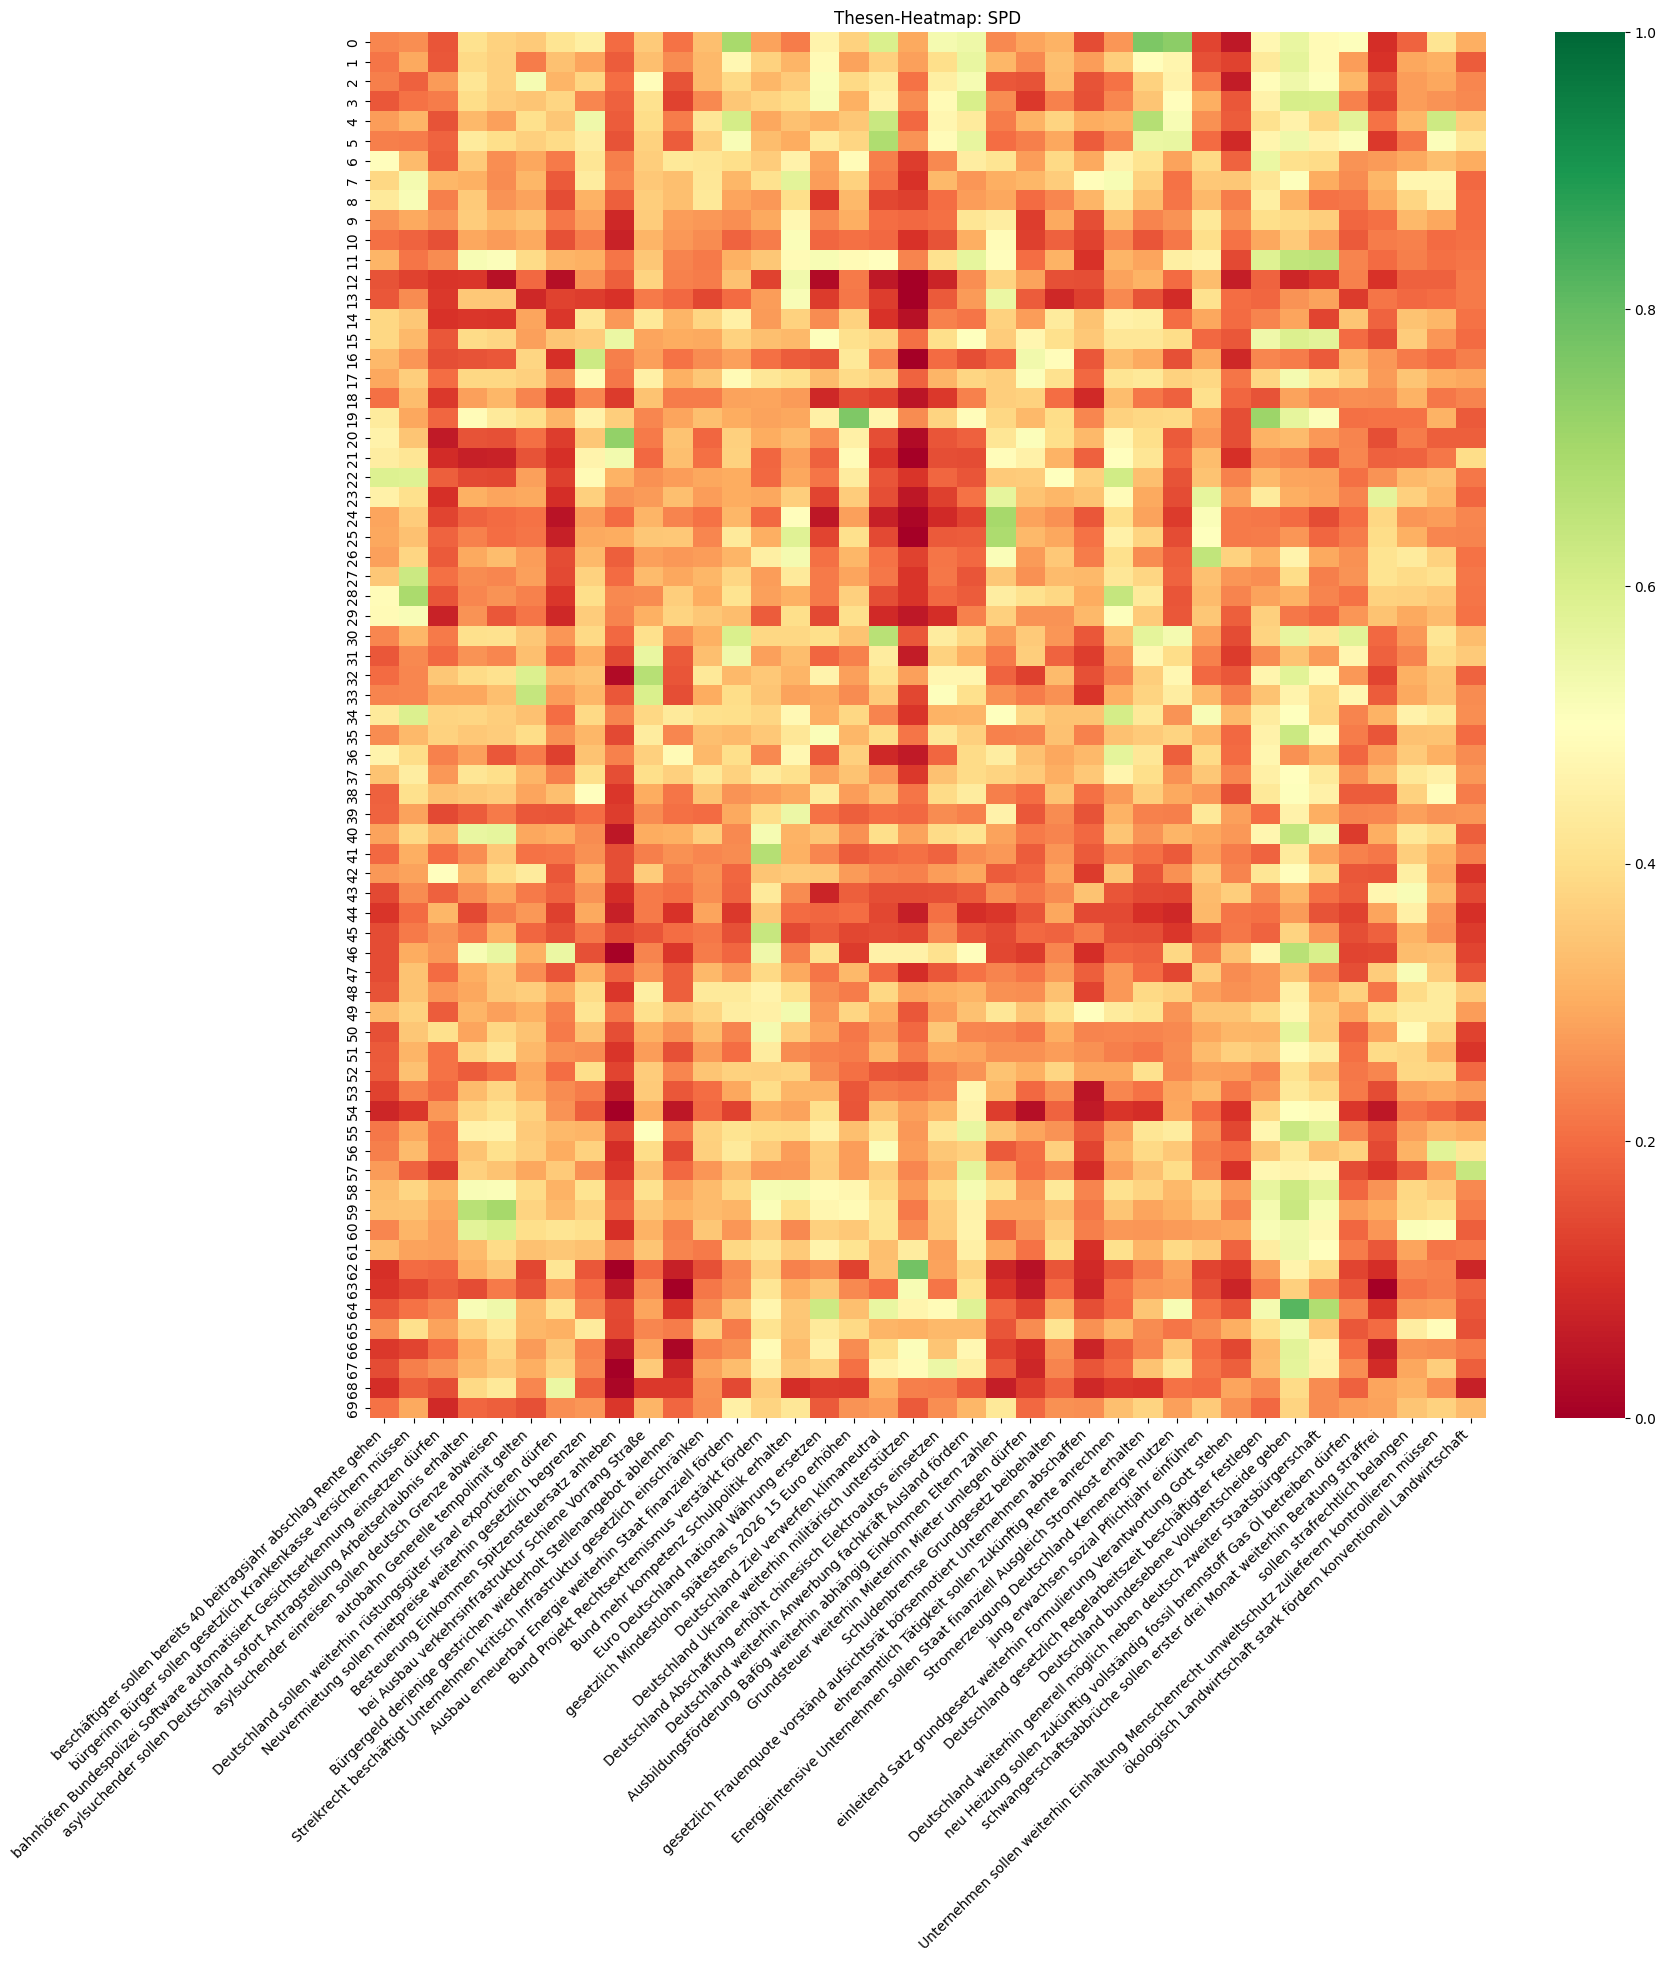

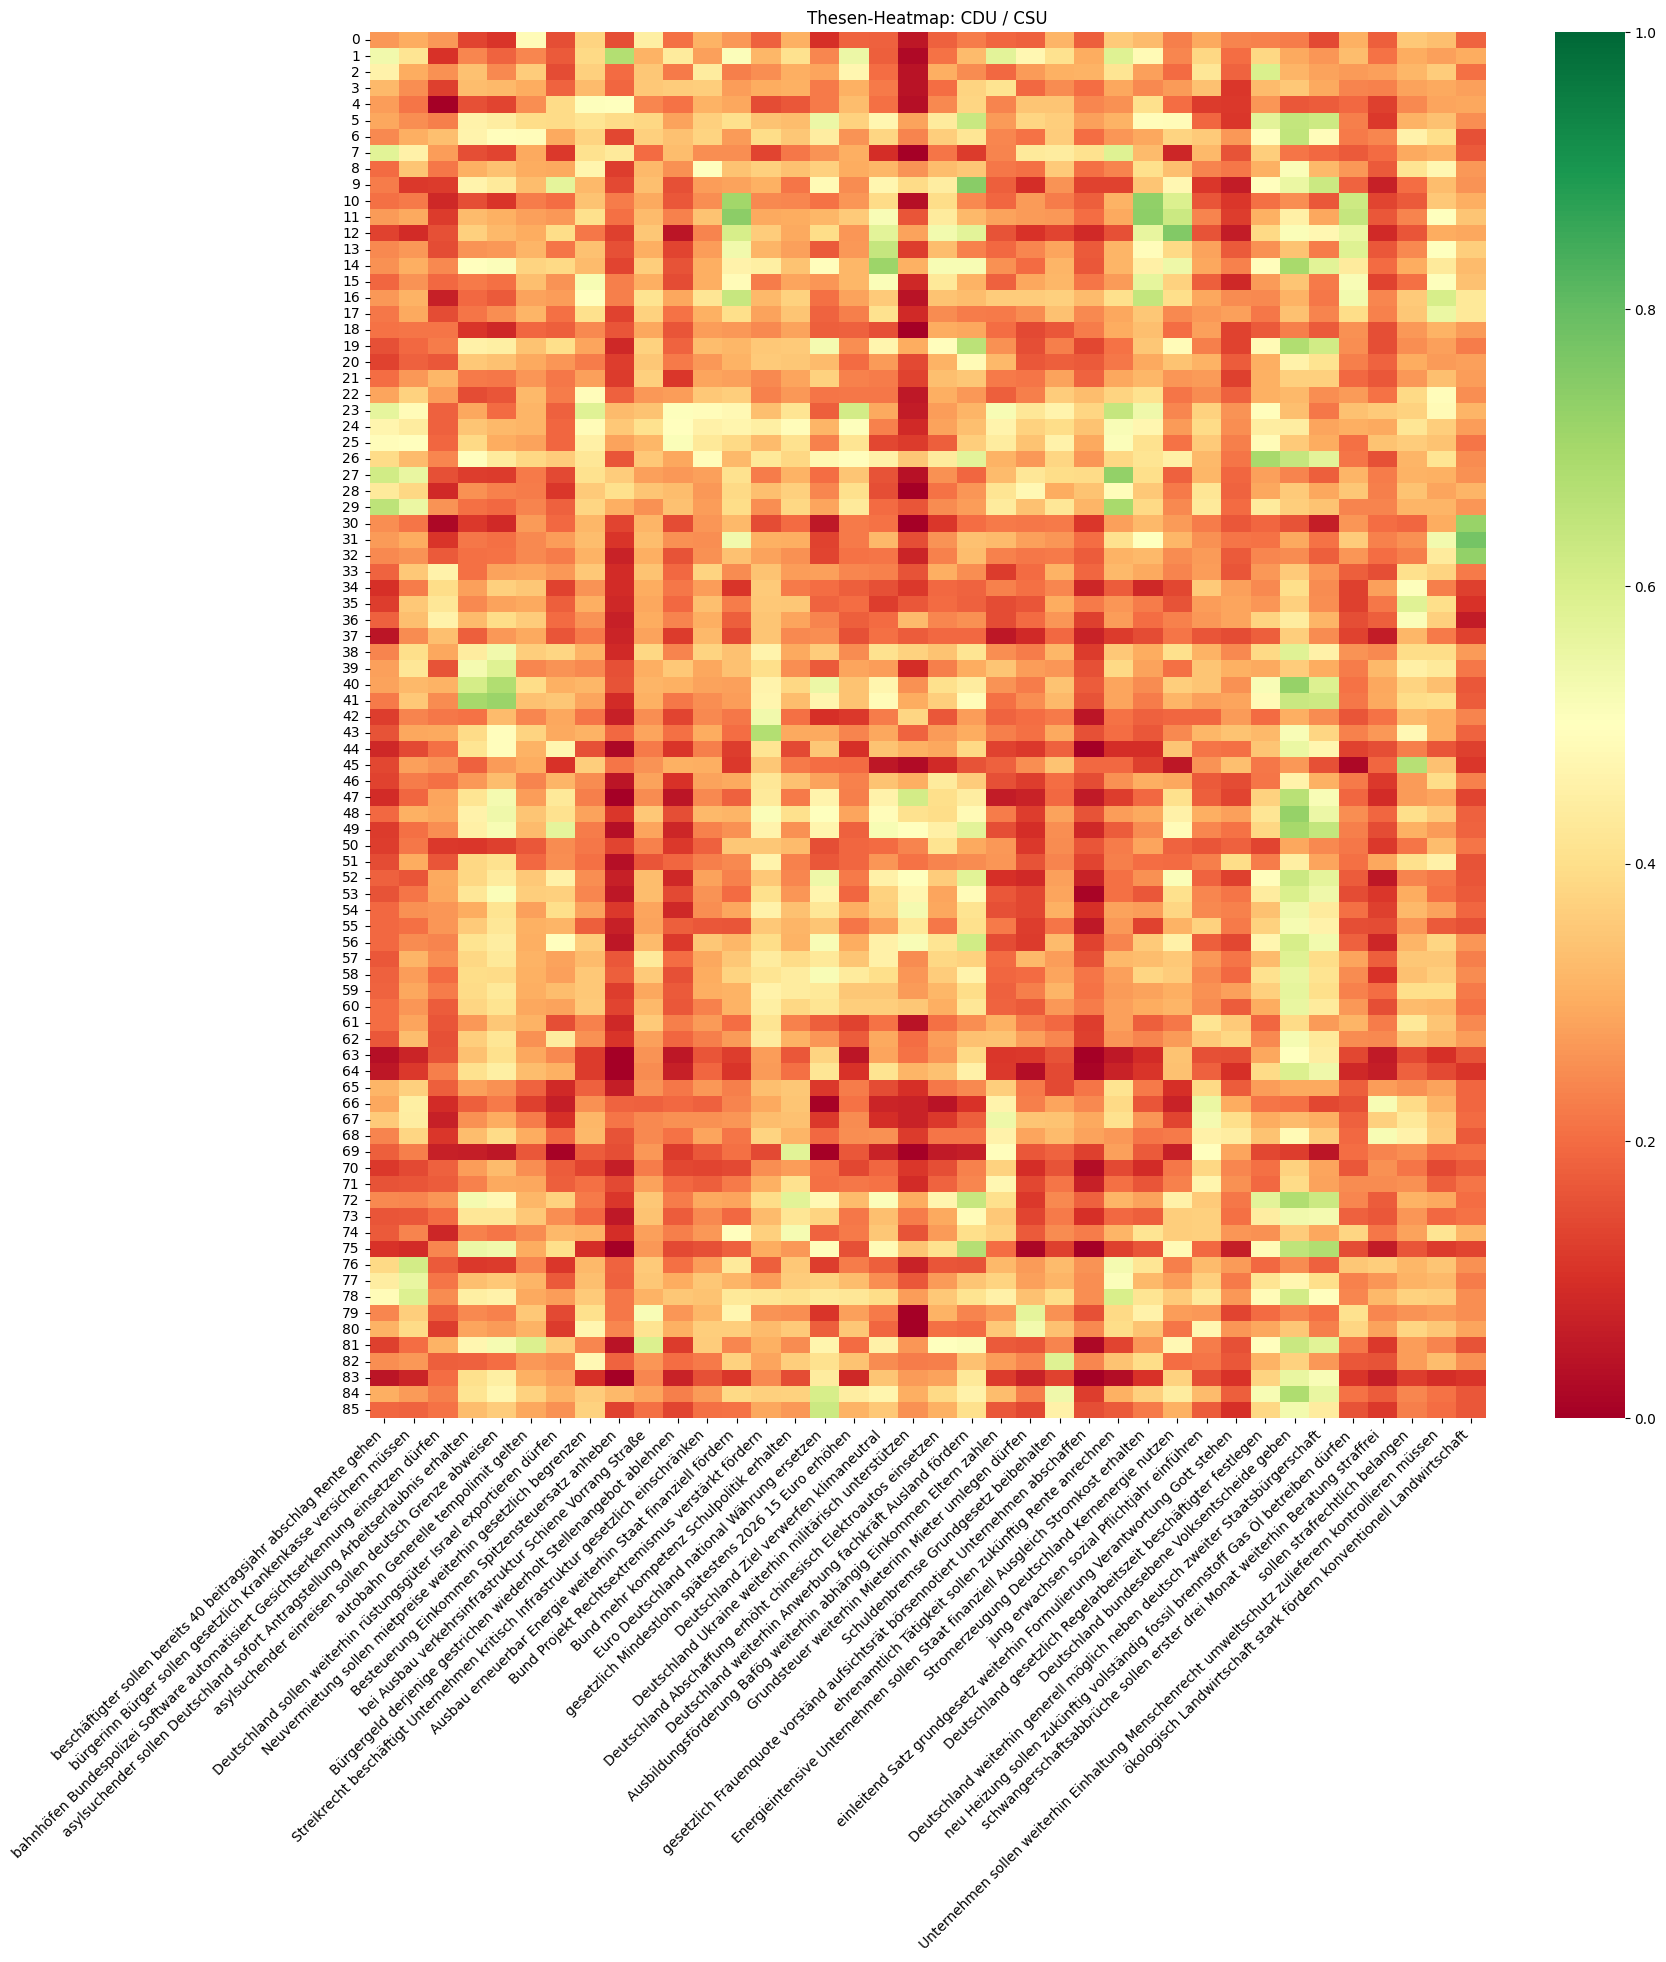

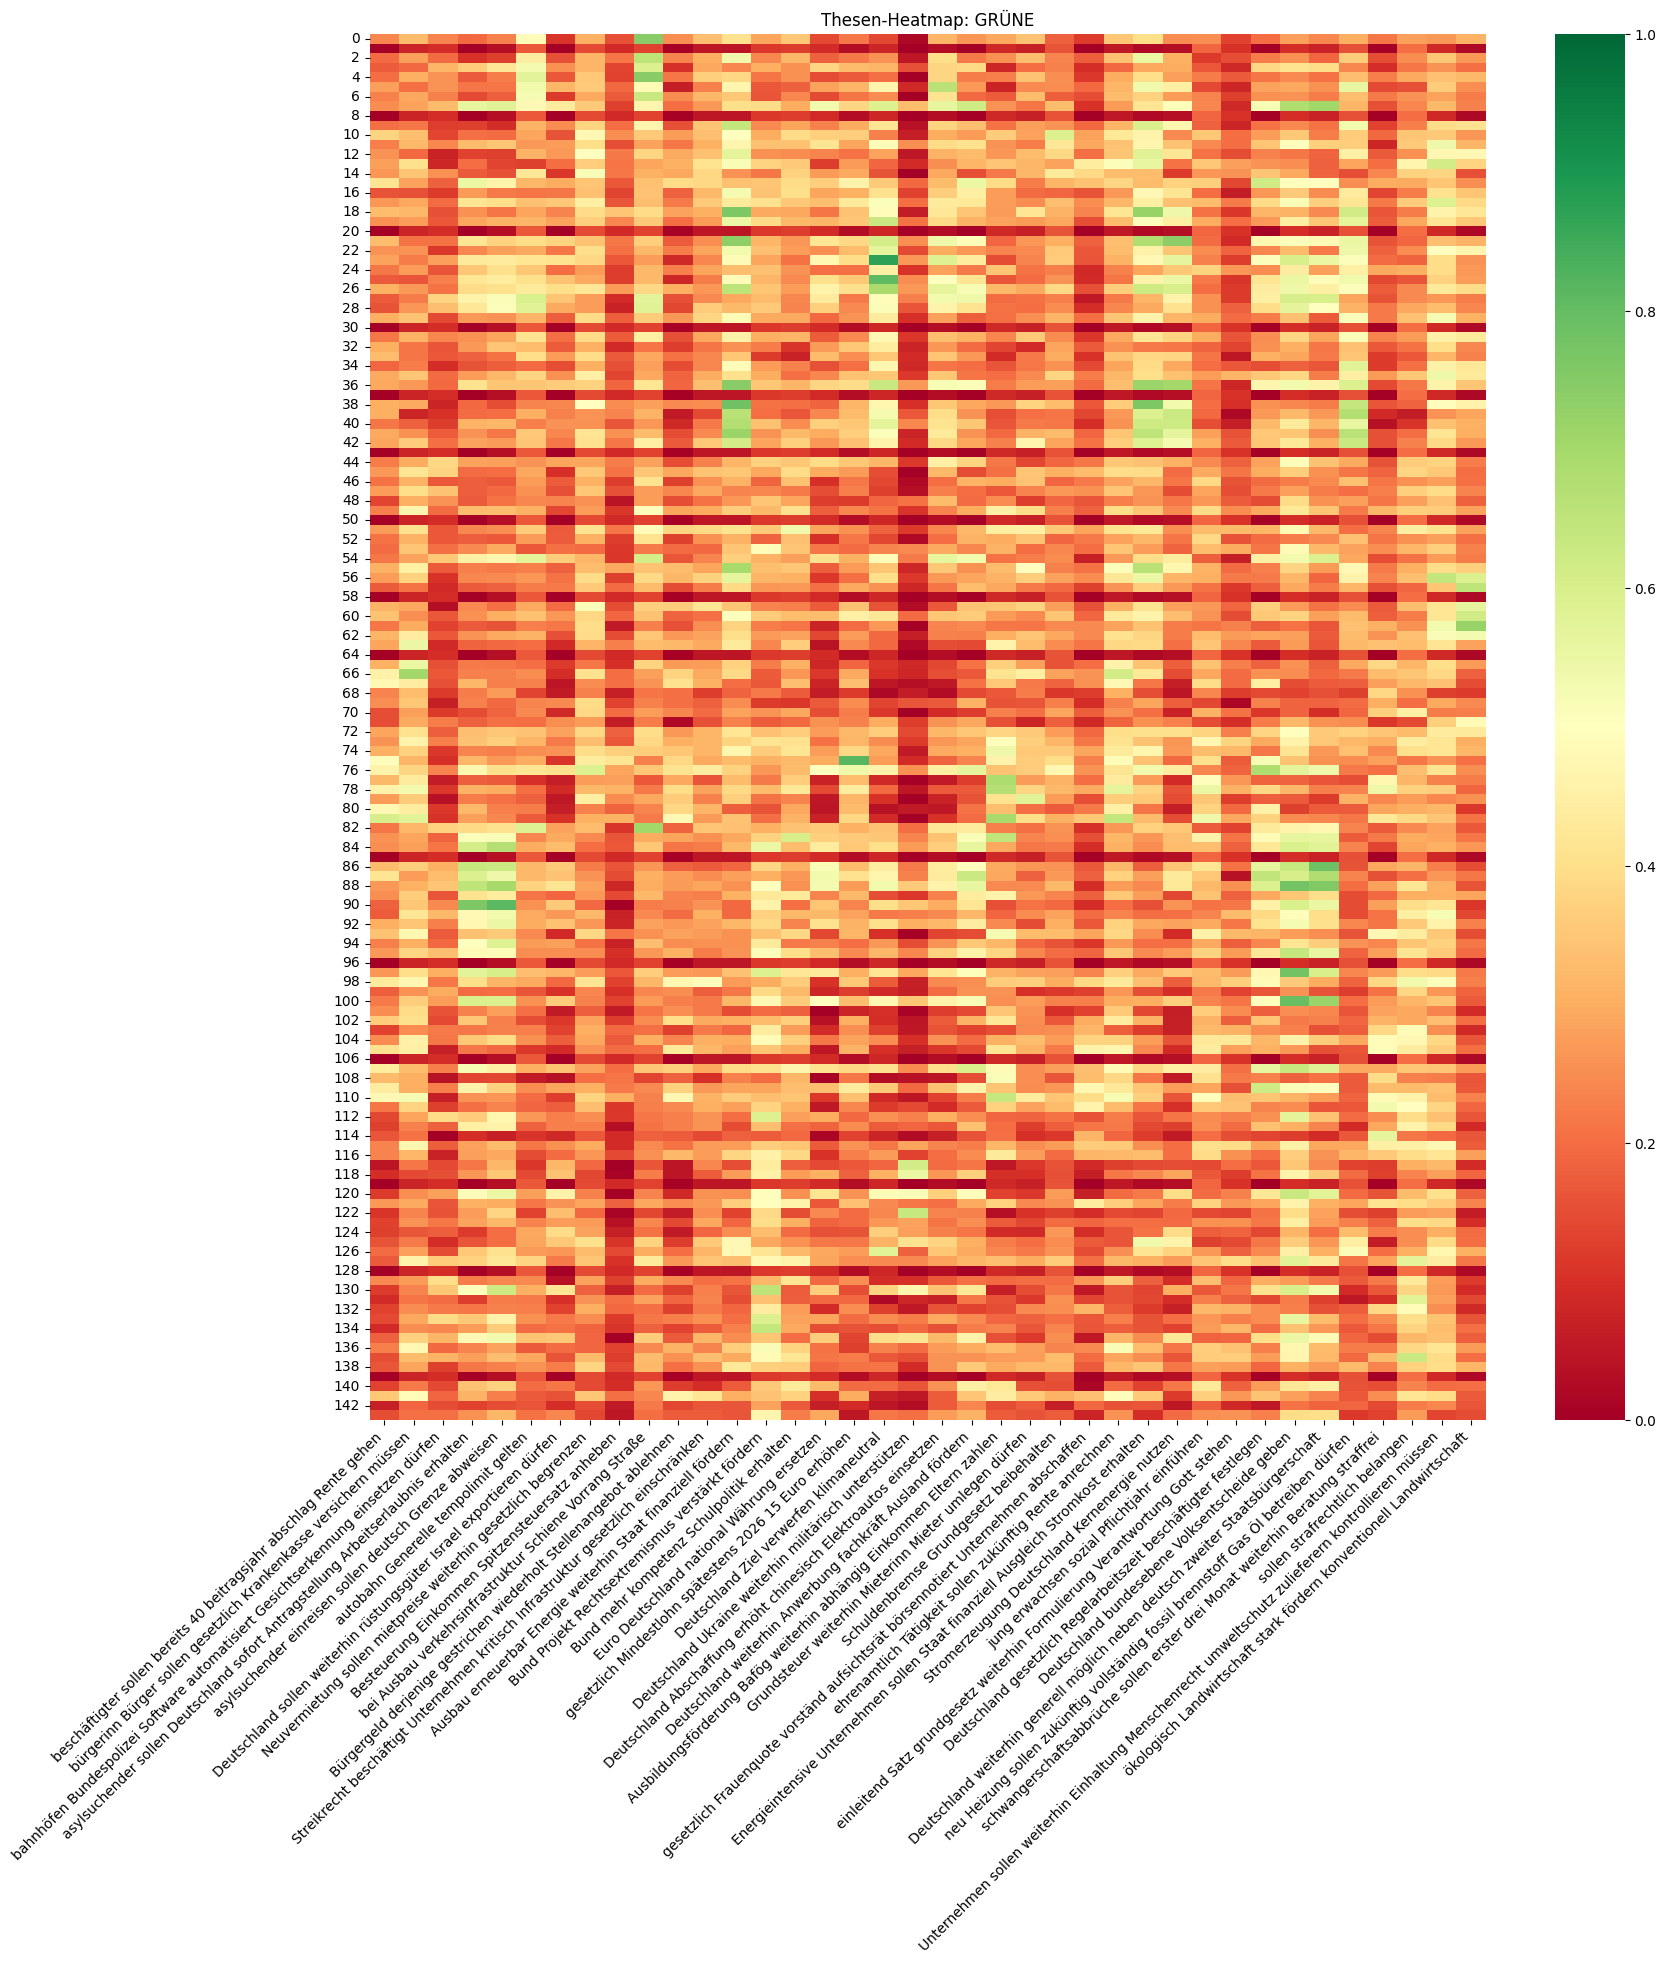

KeyboardInterrupt: 

In [81]:
# Liste der Parteien und Thesen
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These_lemmatized'].tolist()
predicted_these_text_dfs_dict = {}
predicted_these_text_df = predicted_theses_df.copy()

# Schleife über die Parteien
for party_str in parties_list:
    # Filtern der Daten für die aktuelle Partei
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    
    # Entfernen von Zeilen mit NaN-Werten
    party_df = party_df.dropna()
    
    # Extrahieren der Thesen für die aktuelle Partei
    party_text_list = party_df['Text_lemmatized'].to_list()
    
    # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
    similarity_df = pd.DataFrame(columns=['party_text'] + Labled_theses_list)

    # Berechnung der Ähnlichkeit für jede Partei-These
    for party_text in party_text_list:
        party_these_embedding = model.encode(party_text)
        row = [party_text]

        # Berechnung der Kosinusähnlichkeit für jede labelte These
        for label_these in Labled_theses_list:
            label_these_embedding = model.encode(label_these)
            similarity_score = (cosine_similarity(party_these_embedding.reshape(1, -1), label_these_embedding.reshape(1, -1))[0][0])
            row.append(similarity_score)

        similarity_df.loc[len(similarity_df)] = row

    # Visualisierung der Ähnlichkeiten als Heatmap
    plt.figure(figsize=(18, 18))
    sns.heatmap(similarity_df[Labled_theses_list],
                cmap='RdYlGn',
                annot=False,
                vmax=1,
                vmin=0,
                #yticklabels=party_df['These']
                )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    # Durchschnittliche Ähnlichkeit für jede Partei
    predicted_these_text_dfs_dict[party_str] = similarity_df
    predicted_these_text_df[party_str] = similarity_df[Labled_theses_list].max().tolist()
    

file_name_all_similaritys = f'paraphrase-multilingual-mpnet-base-v2_Theses_Text_all_similaritys.pkl' 
file_name_max_similaritys = f'paraphrase-multilingual-mpnet-base-v2_Theses_Text_max_similaritys.parquet' 


with open(file_name_all_similaritys, 'wb') as f:
    pickle.dump(predicted_these_text_dfs_dict, f)

predicted_these_text_df.to_parquet(file_name_max_similaritys, index=False)


In [ ]:
calc_prediction_scores_func(predicted_these_text_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.570985,0.576083,0.555409,0.596040,0.59604,0.634072
1,MAE,0.473684,0.473684,0.456140,0.508772,0.50000,0.552632
2,R²,-2.207419,-2.087330,-2.072030,-2.684757,-2.37500,-3.160032


In [ ]:
predicted_these_text_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.197280,0.500008,0.326008,0.398423,0.268547,0.306494
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.390431,0.460823,0.430797,0.437154,0.325244,0.487329
2,An Bahnhöfen soll die Bundespolizei Software z...,0.104083,0.322967,0.251852,0.197439,0.094315,0.274307
3,Asylsuchende sollen in Deutschland sofort nach...,0.204273,0.556813,0.341139,0.453674,0.318338,0.453685
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.287283,0.570393,0.445605,0.488124,0.378472,0.445961
5,Auf allen Autobahnen soll ein generelles Tempo...,0.237328,0.518605,0.299764,0.290325,0.276073,0.498351
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.340289,0.432624,0.332886,0.470023,0.296665,0.522621
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.310376,0.482463,0.447930,0.448431,0.379818,0.500345
8,Bei der Besteuerung von Einkommen soll der Spi...,0.309725,0.361109,0.370630,0.341633,0.469712,0.419132
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.294518,0.635704,0.405744,0.343092,0.322955,0.629296


In [ ]:
compare_df = pd.concat([predicted_these_text_df['These'], (predicted_these_text_df.select_dtypes(include='number')-label_these_num_df.select_dtypes(include='number'))], axis=1)

compare_df


,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.289804,0.190651,0.267291,0.335283,-0.278462,0.283109
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.342395,-0.286094,-0.238136,0.432123,-0.376852,0.387544
2,An Bahnhöfen soll die Bundespolizei Software z...,-0.434401,0.235920,0.271705,-0.459176,0.264656,0.298544
3,Asylsuchende sollen in Deutschland sofort nach...,0.370436,-0.255699,-0.314413,0.487750,-0.284700,0.164605
4,"Asylsuchende, die über einen anderen EU-Staat ...",-0.223627,0.519840,0.438173,-0.072912,0.441063,-0.021706
5,Auf allen Autobahnen soll ein generelles Tempo...,0.181402,-0.302404,-0.454652,0.396434,-0.315113,0.306670
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,-0.487609,-0.443639,-0.366299,-0.054546,0.136022,-0.235940
7,Bei Neuvermietungen sollen die Mietpreise weit...,-0.229195,-0.264401,-0.131228,0.421787,-0.109383,0.554337
8,Bei der Besteuerung von Einkommen soll der Spi...,0.241309,-0.463938,-0.188097,0.445110,-0.237598,0.367236
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.280029,-0.166132,-0.301109,0.634468,-0.112408,0.501183


In [106]:
compare_df.drop(columns='These').mean()

CDU / CSU   -0.195748
GRÜNE       -0.005942
SPD         -0.145566
AfD         -0.056185
Die Linke   -0.148214
FDP          0.027012
dtype: float64

In [100]:
compare_df.drop(columns='These').min().min()

np.float64(-0.7292503168185552)